In [1]:
# python libs
import glob
import os

# data libs
import pandas as pd
import torch

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

from IPython.display import display, clear_output

from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.manifold import TSNE
import matplotlib as mpl

In [4]:
from Bio.Seq import Seq
from Bio import SeqIO

In [5]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
from fuzzywuzzy import process

### Functions and imports

In [7]:
from esm import pretrained
from esm.data import BatchConverter

In [8]:
from esm import pretrained
from esm.data import BatchConverter
import torch

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.manifold import TSNE

In [9]:
import subprocess
from IPython.display import display, clear_output

In [10]:
def get_residue_loc(row, col, base=0):
    '''
    given an aligned protein (with gaps) as Series
    get the residue number of the requested column in the protein
    (i.e. the original index of the residue)
    '''
    
    # make sure it's not a gap
    if row.loc[col] == '-':
        raise KeyError('Desired col is a gap in this sequence')

    # base must be zero or one
    assert base in [0, 1]
    
    loc = row.index.get_loc(col)
    row_slice = row.iloc[:loc+1]
    _str = ''.join(row_slice[row_slice.eq('-')].astype(str))
    
    return len(_str) + base

In [11]:
def forward_transform(y):
    eps = 1e-6  # to avoid division by zero
    y = np.clip(y, a + eps, b - eps)
    return np.log((y - a) / (b - y))
a, b = -20, 120
def inverse_transform(y_prime):
    return a + (b - a) / (1 + np.exp(-y_prime))

# Outline

Parse metadata and collate data for metagenomic datasets

## Functions

In [142]:
def get_aln_df(file):
    with open(file, 'r') as handle:
        lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

    aln_df = pd.concat(lines, axis=1).T
    
    return aln_df


def get_esm_input(aln_df):
    data = []
    # for each protein
    for index, row in aln_df.iterrows():
        seq = ''.join([s for s in row.values if s != '-'])
    
        # Clean sequence to ensure valid AAs only
        VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
        clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
        
        if len(seq) == len(clean_seq):
            # Batch convert
            data.append((index, clean_seq))
        else:
            print('Uh oh, invalid AA!')
            
    return data

def assemble_col_dataset(aln_df, labels):
    col_datasets = {}
    # for each column in the alignment
    for col in aln_df.columns:
        # get proteins which have a residue (not a gap) at this col
        rows = aln_df[~aln_df[col].eq('-')].index
        col_str = f'{len(rows)} rows available for col {col}'
    
        # get the rows
        subset = aln_df.loc[rows, :]
        # get which residue this corresponds to in each protein, zero-indexed
        indeces = subset.apply(lambda row: get_residue_loc(row, col=col, base=0), axis=1)
    
        if len(indeces) > 0:
            # for each protein
            temp_list = []
            for j, (index, item) in enumerate(indeces.items()):
                
                # progress bar
                if j % 100 == 0:
                    progress_str = '#' * int((j / len(indeces)) * 20)
                    fill_str = '-' * (20-len(progress_str))
                    print(col_str + f' |{progress_str}{fill_str}|     ', end='\r')
        
                # get the embedding for that site in that protein
                ploc_in_reps = labels.index(index)
                tensor = pd.Series(data=reps.detach()[ploc_in_reps, item+1, :].numpy(), name=index)
                temp_list.append(tensor)
                
            col_datasets[col] = pd.concat(temp_list, axis=1)
            
    return col_datasets

def plot_predictions(col_datasets, y):
    predictions = []
    for col in list(col_datasets.keys()):
        # if col < 100 and col > 10: #not col in list(range(150, 160)) + list(range(190, 210)): 
        dataset = col_datasets[col].T.reindex(index=y.protein).dropna()
        predictions.append(pd.Series(index=dataset.index, data=inverse_transform(models[col].predict(dataset)), name=col))
    
    y_pred = pd.concat(predictions, axis=1) 
    # y_pred.index = [s.split('|')[2].split('_hmmsea')[0] for s in y_pred.index]
    y_mean = y_pred.mean(1).rename('predicted')
    plotdf = pd.merge(y_mean, 
             y, 
             left_index=True, right_on='protein', how='inner')
    
    fig, ax = plt.subplots(figsize=(6,6))
    sns.scatterplot(data=plotdf, y='predicted', x='env temp', linewidth=0, alpha=0.65, s=5, )
    
    # for index, row in plotdf.iterrows():
    #     if '032' in myco_md_full.set_index('Run')['sample'].loc[index]:
    #         ax.annotate( myco_md_full.set_index('Run')['sample'].loc[index], (row['Temperature Optimum (℃)'], row['predicted']))
    #         plt.scatter(y=row['predicted'], x=row['Temperature Optimum (℃)'], c='r')
    
    _x, _y = 10, 100
    rmse = 12
    plt.plot((_x, _y), (_x-rmse, _y-rmse), color='r', zorder=0)
    plt.plot((_x, _y), (_x+rmse, _y+rmse), color='r', zorder=0)
    plt.plot((_x, _y), (_x, _y), zorder=0)
    
    ax.axhline(80, color='grey')
    
    sns.despine()

    return plotdf

# ax.set_title('Mycobacteria')

## Setup

In [12]:
aln_df = get_aln_df('./../data/20240122_all_adks_filtered_nogap.afa') 

aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [13]:
# Load ESM2 model and alphabet
model, alphabet = pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

ESM2(
  (embed_tokens): Embedding(33, 320, padding_idx=1)
  (layers): ModuleList(
    (0-5): 6 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=320, out_features=320, bias=True)
        (v_proj): Linear(in_features=320, out_features=320, bias=True)
        (q_proj): Linear(in_features=320, out_features=320, bias=True)
        (out_proj): Linear(in_features=320, out_features=320, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=320, out_features=1280, bias=True)
      (fc2): Linear(in_features=1280, out_features=320, bias=True)
      (final_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=120, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((320,), eps=1e-05, elementwis

In [17]:
# load predictive models
with open('./../data/proclam/esm2_t6_8M_UR50D/models.pickle', 'rb') as handle:
    models = pickle.load(handle)

# Colman 2024
The data from Colman 2024 is pre-assembled and deposited in both IMG and NCBI: IMG bins and NCBI genomes. This code gets the information associated with both the IMG and NCBI bins.

## Metadata

In [17]:
# data from paper
sample_md = pd.read_excel('./../data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx', sheet_name='Dataset S1 - Sample Information')
# metadata for MAGs
mag_md = pd.read_excel('./../data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx', sheet_name='Dataset S2 - MAG Information')

In [18]:
# get the NCBI project names
prjnas = [id for id in mag_md['IMG Bin Accession / NCBI Accession / IMG metagenome accession'].unique() if 'PR' in str(id)]
prjnas

['PRJNA1019763', 'PRJNA568221', 'PRJNA568220', 'PRJNA791658', 'PRJNA800390']

Here: go to NCBI and get the metadata for each of these projects

In [19]:
# get all the genome assembly accessions from the projects
_list = []
for f in glob.glob('./../data/validation_datasets/Colman2024/md/*ncbi.tsv'):
    _list.append(pd.read_csv(f, sep='\t'))

with open('./../data/validation_datasets/Colman2024/md/PRJNA_accessions.txt', 'w') as handle:
    handle.write('\n'.join(list(pd.concat(_list)['Assembly Accession'].unique())))


In [20]:
img_mgs = [str(id) for id in mag_md['IMG Bin Accession / NCBI Accession / IMG metagenome accession'].unique() if not '_' in str(id) and not 'PR' in str(id)]
','.join(img_mgs)

'3300034404,3300033781,35332273,3300029625'

In [21]:
img_gs = [str(id).split('_')[0] for id in mag_md['IMG Bin Accession / NCBI Accession / IMG metagenome accession'].unique() if '_' in str(id)]
','.join(list(set(img_gs)))

'3300045908,3300045866,3300045870,3300045879,3300045904,3300045890,3300045859,3300045876,3300045871,3300045889,3300045877,3300045875,3300045864,3300045865,3300045899,3300045900,3300045872,3300045882,3300045867,3300045901,3300045891,3300045862,3300045881,3300045863,3300045869,3300045883,3300045887,3300045888,3300045860,3300045873,3300045878,3300045868,3300045874,3300045880'

In [22]:
len(list(set(img_gs)))

34

Each of the NCBI Projects were downloaded with the Datasets CLI. Each of the IMG metagenomes / genomes were downloaded through IMG.

## Step 1. annotate genomes
```
ls *.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./
cat ./genomes/*_adk.faa > adks.faa

# now not used
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

## Step 2. More metadata parsing
Getting the temperature of each sample

In [36]:
md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx',
              sheet_name='Dataset S1 - Sample Information')

In [37]:
sample2temp = md.set_index(['Metagenome ID'])['Temp (oC)'].dropna()
sample2temp.head()

Metagenome ID
CRH-RHS      83.7
CRH-Alice    77.4
GCR01        83.2
GCR02        76.1
GCR04        66.8
Name: Temp (oC), dtype: object

Now need to figure out the NCBI / IMG ID of each metagenome, so the metagenomes can be matched to sample

In [38]:
mag_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Colman2024/md/41467_2024_51841_MOESM4_ESM.xlsx',
              sheet_name='Dataset S2 - MAG Information')
mag_md.head()

,Metagenome,Bin ID,IMG Bin Accession / NCBI Accession / IMG metagenome accession,mOTU ID,Phylogenetic Distance to Root,Percent_binned_population,Percent_reads_mapped,Domain,Completeness,Contamination,Classification,N50,GC,Bin Size (Mbp)
0,CRH-Alice,CRH-Alice.S.bin.1,PRJNA1019763,Otu034,2.119330,6.698151,1.857324,Archaea,98.81,0.00,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,55974,33.9,1.614831
1,CRH-Alice,CRH-Alice.S.bin.2,PRJNA1019763,Otu001,2.213667,30.072629,6.599919,Archaea,72.74,1.36,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,5342,46.0,1.278090
2,CRH-Alice,CRH-Alice.S.bin.3,PRJNA1019763,Otu019,2.381968,18.975250,3.564592,Archaea,86.33,0.00,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,14895,37.6,1.093998
3,CRH-Alice,CRH-Alice.S.bin.4,PRJNA1019763,Otu006,2.273421,7.287747,1.579423,Archaea,87.38,0.00,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,29406,67.2,1.262116
4,CRH-Alice,CRH-Alice.S.bin.5,PRJNA1019763,Otu018,2.128901,4.512406,1.265594,Archaea,99.40,0.00,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,72036,38.1,1.633354


In [40]:
# merge MAG metadata (information on MAGS) with mapping of sample to temperature
merged_md = pd.merge(mag_md, sample2temp, left_on='Metagenome', right_index=True).rename(columns={'IMG Bin Accession / NCBI Accession / IMG metagenome accession':'accession'})
# clean up temp column
merged_md['Temp (oC)'] = merged_md['Temp (oC)'].apply(lambda x: float(str(x).replace('*', '')))

# clean up accession column
merged_md['accession_clean'] = merged_md['accession'].apply(lambda x: str(x).split('_')[0])

merged_md.head()

,Metagenome,Bin ID,accession,mOTU ID,Phylogenetic Distance to Root,Percent_binned_population,Percent_reads_mapped,Domain,Completeness,Contamination,Classification,N50,GC,Bin Size (Mbp),Temp (oC),accession_clean
0,CRH-Alice,CRH-Alice.S.bin.1,PRJNA1019763,Otu034,2.119330,6.698151,1.857324,Archaea,98.81,0.00,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,55974,33.9,1.614831,77.4,PRJNA1019763
1,CRH-Alice,CRH-Alice.S.bin.2,PRJNA1019763,Otu001,2.213667,30.072629,6.599919,Archaea,72.74,1.36,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,5342,46.0,1.278090,77.4,PRJNA1019763
2,CRH-Alice,CRH-Alice.S.bin.3,PRJNA1019763,Otu019,2.381968,18.975250,3.564592,Archaea,86.33,0.00,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,14895,37.6,1.093998,77.4,PRJNA1019763
3,CRH-Alice,CRH-Alice.S.bin.4,PRJNA1019763,Otu006,2.273421,7.287747,1.579423,Archaea,87.38,0.00,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,29406,67.2,1.262116,77.4,PRJNA1019763
4,CRH-Alice,CRH-Alice.S.bin.5,PRJNA1019763,Otu018,2.128901,4.512406,1.265594,Archaea,99.40,0.00,d__Archaea;p__Thermoproteota;c__Thermoproteia;...,72036,38.1,1.633354,77.4,PRJNA1019763


In [53]:
merged_md.to_csv('./../data/validation_datasets/Colman2024/md/Colman2024_merged_md.tsv', sep='\t')

In [41]:
merged_md.groupby('Metagenome').agg({'Temp (oC)':'mean', 'accession_clean':'first'}).reset_index() #.sort_values('accession_clean')

,Metagenome,Temp (oC),accession_clean
0,CRH-Alice,77.4,PRJNA1019763
1,CRH-RHS,83.7,PRJNA1019763
2,EvPrim,77.0,3300034404
3,GCR-GGS063P,85.9,PRJNA568221
4,GCR-JHP,88.0,3300033781
...,...,...,...
62,SYL01,76.9,3300045862
63,SYL02,78.1,3300045899
64,SYL03,85.0,3300045872
65,SYL04,71.7,3300045871


In [42]:
adks_file = './../data/validation_datasets/Colman2024/adks.faa'
sequence2genome = {}
with open(adks_file, 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]
    
for r in records:
    if '_genomic' in r.id:
        genome = '_'.join(r.id.split('|')[1].split('_')[:2])
    else:
        genome = r.id.split('|')[1].split('_hmmsearch.tbl')[0][:-2]

    sequence2genome[r.id] = genome

In [45]:
pd.Series(sequence2genome).to_csv('./../data/validation_datasets/Colman2024/md/Colman2024_sequence2genome.tsv', sep='\t')

This next part is annoying because as far as I can tell, for the NCBI genomes, the bin id in the metadata doesn't exactly match the name in the NCBI metadata, so we have to do some fuzzy matching.

In [47]:
print('test')

test


In [79]:
genome2temp = {}
genome2tax = {}
for index, row in merged_md.iterrows():
    
    print('\nMatching for ', row['Bin ID'])
    # the bioprojects contained genomes from different sites, which means
    # we need to figure out the exact genome -> site -> temp match
    if "PRJNA" in str(row['accession']):
        path = f'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Colman2024/md/{row["accession"]}_ncbi.tsv'
        prj_md = pd.concat([pd.read_csv(file, sep='\t').assign(prjna=file.split('/')[-1].split('_ncbi')[0]) for file in glob.glob(path)])
        # get 
        bin_id = row['Bin ID']
        # some specific catches
        if 'Sed.bin' in bin_id:
            bin_id = bin_id.replace('Sed.bin.', 'Bin S')
            
        if any(s in bin_id for s in ['NMC-RSWP', 'NMC-RSWS', 'NMC-RSNS', 'NMC-RSNP', 'NMC-RSEP', 'GCR-GGS063P']):
            bin_id = ''.join(bin_id.split('_')[1:])

        if 'GOPA-' in bin_id:
            bin_id = bin_id.replace('GOPA-', '')

        mapping = prj_md.groupby('Organism Infraspecific Names Isolate').first()['Assembly Accession'].dropna()
        match, score = process.extractOne(bin_id, mapping.index)

        if 'GCR-JHS'in bin_id:
            score = 0
            
        if score > 0:
            print('MG ID:', row['Metagenome'], 'Project ID', row['accession'])
            print('Attempting to match bin:', bin_id)
            print('Match', match, ' with genomes:', mapping[match], f'. Score: {score}')
            print()
        # else:
            # print('Matched above 90:', match, bin_id)
            genome2temp[mapping[match]] = row['Temp (oC)']
            genome2tax[mapping[match]] = row['Classification'].split(';')[0]
        
        # print(row['Bin ID'], mapping)

    else:
        genome2temp[row['accession_clean']] = row['Temp (oC)']
        print('Is IMG')
        # print('found IMG genome: ')
        # print(row['Bin ID'], row['accession_clean'], row['Temp (oC)'])
print('-'*80)
print('DONE')


Matching for  CRH-Alice.S.bin.1
MG ID: CRH-Alice Project ID PRJNA1019763
Attempting to match bin: CRH-Alice.S.bin.1
Match Alice.S.bin.1  with genomes: GCA_046537415.1 . Score: 95


Matching for  CRH-Alice.S.bin.2
MG ID: CRH-Alice Project ID PRJNA1019763
Attempting to match bin: CRH-Alice.S.bin.2
Match Alice.S.bin.2  with genomes: GCA_046537395.1 . Score: 95


Matching for  CRH-Alice.S.bin.3
MG ID: CRH-Alice Project ID PRJNA1019763
Attempting to match bin: CRH-Alice.S.bin.3
Match Alice.S.bin.3  with genomes: GCA_046537375.1 . Score: 95


Matching for  CRH-Alice.S.bin.4
MG ID: CRH-Alice Project ID PRJNA1019763
Attempting to match bin: CRH-Alice.S.bin.4
Match Alice.S.bin.4  with genomes: GCA_046537335.1 . Score: 95


Matching for  CRH-Alice.S.bin.5
MG ID: CRH-Alice Project ID PRJNA1019763
Attempting to match bin: CRH-Alice.S.bin.5
Match Alice.S.bin.5  with genomes: GCA_046537295.1 . Score: 95


Matching for  CRH-Alice.S.bin.6
MG ID: CRH-Alice Project ID PRJNA1019763
Attempting to match b

In [85]:
y = pd.Series(sequence2genome).reset_index().rename(columns={'index':'protein', 0:'sample_or_genome'}) #.map(genome2temp).dropna()
y['env temp'] = y['sample_or_genome'].map(genome2temp).astype(float)
print(y.shape)
y = y.dropna()
print(y.shape)
y.head()

(996, 3)
(964, 3)


,protein,sample_or_genome,env temp
0,Ga0311297_1000625_2|3300029625.a_hmmsearch.tbl...,3300029625,61.9
1,Ga0311297_1003370_3|3300029625.a_hmmsearch.tbl...,3300029625,61.9
2,Ga0311297_1004063_24|3300029625.a_hmmsearch.tb...,3300029625,61.9
3,Ga0311297_1005515_15|3300029625.a_hmmsearch.tb...,3300029625,61.9
4,Ga0311297_1006704_22|3300029625.a_hmmsearch.tb...,3300029625,61.9


In [86]:
y.to_csv('./../data/validation_datasets/Colman2024/md/Coleman2024_env_temps.tsv', sep='\t')

# Royo-Llonch 2021

## 1. Getting metagenomes from ENA

In [310]:
from jsonapi_client import Session
import pandas as pd
import requests

In [311]:
import json

def pp(json_obj):
    print(json.dumps(json_obj, indent=2))


In [314]:
tara_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/41564_2021_979_MOESM4_ESM.xlsx',
             sheet_name='Suppl_Table_13')

In [315]:
results = []
complete = []

In [317]:

for ena_id in list(set(tara_md['ENA_ID'].values) - set(complete)):
    
    print(ena_id)
    # get data for this sample
    sample_url = f"https://www.ebi.ac.uk/metagenomics/api/v1/samples/{ena_id}"
    sample_data = requests.get(sample_url).json()
    if 'errors' in sample_data.keys():
        print('metadata retrieval failed:', ena_id)
        continue 
        
    mg_sample_id = sample_data["data"]["id"]

    # get runs for this sample
    run_data = requests.get(sample_data['data']['relationships']['runs']['links']['related']).json()
    # filter to runs that are metagenomics
    mg_runs = [r for r in run_data['data'] if r['attributes']['experiment-type'] == 'metagenomic']

    # for each run
    for run in mg_runs:
        run_id = run['id']
        try:
            assembly_rel = run['relationships']['assemblies']['data'][0]['links']['self']
        except (IndexError, KeyError):
            print(f'No assembly for run {run_id}')  # no assembly for this run

        assembly_id = assembly_rel.split("/")[-1]
        analyses_url = requests.get(assembly_rel).json()['data']['relationships']['analyses']['links']['related']
        analyses = requests.get(analyses_url).json()['data']

        for analysis in analyses:

            analysis_id = analysis['id']

            # skip non-v5 analyses
            if analysis['attributes']['pipeline-version'] != '5.0':
                # print(f'pipeline 5.0 run found for {analysis_id}')
                continue

            # get download links
            try:
                downloads_url = analysis['relationships']['downloads']['links']['related']
                downloads = requests.get(downloads_url).json()['data']
            except KeyError:
                continue

            for d in downloads:
                label = d['attributes']['description'].get('label', '')
                if label == 'Processed contigs':
                    results.append({
                        "ENA_ID": ena_id,
                        "MGY_Run_ID": run_id,
                        "Assembly_ID": assembly_id,
                        "Pipeline_Job_ID": analysis_id,
                        "Pipeline_v":analysis['attributes']['pipeline-version'],
                        "Download_Link": d['links']['self']
                    })
    
    complete.append(ena_id)
    df = pd.DataFrame(results)
    df.to_csv("~/fiererlab/adenylate_kinase_ogt/data/validation_datasets/temp0_20/RoyoLlonch2021/md/metagenomic_assemblies.tsv", sep='\t', index=False)

In [391]:
with open('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/temp0_20/RoyoLlonch2021/genomes/download.sh', 'w') as handle:
    handle.write('#!/bin/bash\nwget ')
    handle.write('\nwget '.join(list(df['Download_Link'].unique())))

## 2. Annotating metagenomes

```
ls *.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./
cat ./genomes/*_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

## 3. more metadata parsing

In [87]:
royo2021_chem_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/41564_2021_979_MOESM4_ESM.xlsx',
                           sheet_name = 'Suppl_Table_04')
royo2021_samp_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/41564_2021_979_MOESM4_ESM.xlsx',
                           sheet_name = 'Suppl_Table_13')

<Axes: xlabel='Temperature', ylabel='Count'>

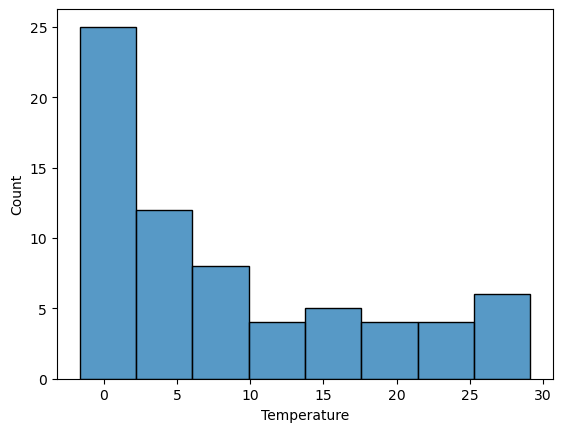

In [88]:
sns.histplot(royo2021_chem_md['Temperature'])

In [89]:
# get metadata of the assemblies
mg_md = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/RoyoLlonch2021/md/metagenomic_assemblies.tsv', sep='\t')
mg_md.head()

,ENA_ID,MGY_Run_ID,Assembly_ID,Pipeline_Job_ID,Pipeline_v,Download_Link
0,ERS494170,ERR598983,ERZ834050,MGYA00590525,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
1,ERS1309625,ERR3589561,ERZ7462832,MGYA00607616,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
2,ERS1308760,ERR3589577,ERZ7462896,MGYA00607594,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
3,ERS1309745,ERR3589576,ERZ7463433,MGYA00607605,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
4,ERS489712,ERR599057,ERZ840938,MGYA00590540,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...


In [90]:
# merge station info with sample info
merged_md = pd.merge(royo2021_chem_md[['Station.label.num', 'PANGAEA.sample.id', 'Temperature', 'Depth.nominal']], 
         royo2021_samp_md[['PANGAEA sample id', 'ENA_ID', 'MetaG/MetaT']],
        left_on='PANGAEA.sample.id',
        right_on='PANGAEA sample id')
merged_md.head()

,Station.label.num,PANGAEA.sample.id,Temperature,Depth.nominal,PANGAEA sample id,ENA_ID,MetaG/MetaT
0,TARA_025_DCM,TARA_E500000331,15.181967,50,TARA_E500000331,ERS488509,MetaG
1,TARA_025_SRF,TARA_E500000178,18.319192,5,TARA_E500000178,ERS488486,MetaG
2,TARA_032_DCM,TARA_A100001037,26.129250,80,TARA_A100001037,ERS488599,MetaG
3,TARA_032_SRF,TARA_A100001035,25.811708,5,TARA_A100001035,ERS488569,MetaG
4,TARA_041_DCM,TARA_B100000287,27.374181,60,TARA_B100000287,ERS489074,MetaG


In [91]:
# add info from assemblies
merged_md = pd.merge(merged_md, mg_md, left_on='ENA_ID', right_on='ENA_ID')
merged_md.head()

,Station.label.num,PANGAEA.sample.id,Temperature,Depth.nominal,PANGAEA sample id,ENA_ID,MetaG/MetaT,MGY_Run_ID,Assembly_ID,Pipeline_Job_ID,Pipeline_v,Download_Link
0,TARA_025_DCM,TARA_E500000331,15.181967,50,TARA_E500000331,ERS488509,MetaG,ERR599153,ERZ841978,MGYA00590446,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
1,TARA_025_DCM,TARA_E500000331,15.181967,50,TARA_E500000331,ERS488509,MetaG,ERR599094,ERZ841404,MGYA00590499,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
2,TARA_025_SRF,TARA_E500000178,18.319192,5,TARA_E500000178,ERS488486,MetaG,ERR599043,ERZ840593,MGYA00590542,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
3,TARA_025_SRF,TARA_E500000178,18.319192,5,TARA_E500000178,ERS488486,MetaG,ERR598951,ERZ829891,MGYA00593132,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
4,TARA_032_DCM,TARA_A100001037,26.129250,80,TARA_A100001037,ERS488599,MetaG,ERR599097,ERZ841426,MGYA00590493,5.0,https://www.ebi.ac.uk/metagenomics/api/v1/anal...


In [92]:
# check all Assemblies have 1 unique temperature
print('Assemblies w/ multiple temps (not good):', (merged_md.groupby('Assembly_ID').apply(lambda x: len(x['Temperature'].unique())) != 1).sum())



Assemblies w/ multiple temps (not good): 0


In [94]:
# mapping of assembly to temperature
assembly2temp = merged_md.groupby('Assembly_ID').first()['Temperature']
assembly2temp.head()

Assembly_ID
ERZ7462166   -1.649738
ERZ7462167    2.507887
ERZ7462186   -0.479225
ERZ7462236   -0.409335
ERZ7462311    2.569400
Name: Temperature, dtype: float64

In [96]:
with open('./../data/validation_datasets/RoyoLlonch2021/adks.faa', 'r') as handle:
    ids = [r.id for r in SeqIO.parse(handle, format='fasta')]
y = pd.Series(index=ids, data=ids, name='env temp')

In [97]:
y = y.reset_index().rename(columns={'index':'protein'})
y['sample_or_genome'] = y['protein'].apply(lambda x: x.split('|')[1].split('_FASTA')[0])
y['env temp'] = y['sample_or_genome'].map(assembly2temp)
y

,protein,env temp,sample_or_genome
0,ERZ7462166.3-NODE-3-length-248082-cov-115.2826...,-1.649738,ERZ7462166
1,ERZ7462166.19-NODE-19-length-118314-cov-159.44...,-1.649738,ERZ7462166
2,ERZ7462166.38-NODE-38-length-105504-cov-8.0167...,-1.649738,ERZ7462166
3,ERZ7462166.39-NODE-39-length-105183-cov-15.189...,-1.649738,ERZ7462166
4,ERZ7462166.42-NODE-42-length-103804-cov-196.74...,-1.649738,ERZ7462166
...,...,...,...
8031,ERZ842953.1092676-NODE-2109637-length-664-cov-...,19.783275,ERZ842953
8032,ERZ842953.1096368-NODE-2116667-length-1090-cov...,19.783275,ERZ842953
8033,ERZ842953.1097691-NODE-2119186-length-3244-cov...,19.783275,ERZ842953
8034,ERZ842953.1098190-NODE-2120116-length-1339-cov...,19.783275,ERZ842953


In [98]:
y.to_csv('./../data/validation_datasets/RoyoLlonch2021/md/RoyoLlonch2021_env_temps.tsv', sep='\t')

In [346]:
with open('./../data/validation_datasets/RoyoLlonch2021/keeplength_adk_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

royo2021_aln_df = pd.concat(lines, axis=1).T

royo2021_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,224,225,226,227,228,229,230,231,232,233
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,M,-,N,I,I,L,L,G,P,P,...,I,L,D,N,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,-,G,I,V,M,L,G,A,P,...,A,L,L,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,M,-,R,L,I,L,L,G,A,P,...,A,L,G,-,-,-,R,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,M,-,R,L,L,I,M,G,P,Q,...,E,L,T,K,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,-,-,A,I,L,I,L,G,A,P,...,V,L,E,Y,-,L,L,E,K,-


In [347]:
data = []
for index, row in royo2021_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
    
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [348]:
%%time
# compute representations from sixth layer
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 42min 48s, sys: 44min 17s, total: 1h 27min 6s
Wall time: 8min 25s


In [349]:
# make a df
cls_embedding = pd.DataFrame(index=[l.split('|')[1] for l in labels], data=reps[:, 0, :])

In [350]:
tsne = TSNE(n_components=2, random_state=143, perplexity=50)
embedding_2d = tsne.fit_transform(cls_embedding)

In [351]:
plotdf = pd.DataFrame(embedding_2d, index=cls_embedding.index)

In [352]:
plotdf.head()

,0,1
GB_GCA_000016765.1,-4.304157,-47.253349
GB_GCA_000242235.1,20.049311,-24.422789
GB_GCA_000283575.1,-19.949972,-17.150942
GB_GCA_000376885.1,-57.305477,-42.256126
GB_GCA_000411155.1,54.273739,-73.965363


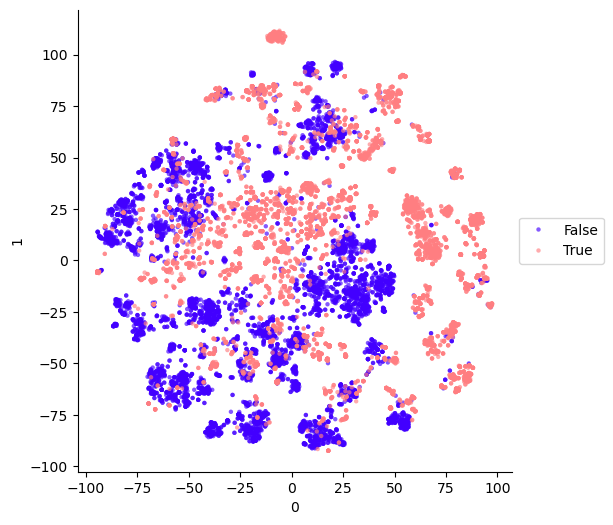

In [353]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, x=0, y=1, s=10, hue=plotdf.index.str.contains('tbl'), palette='gnuplot2', 
                linewidth=0, alpha=0.65)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_aspect('equal')
sns.despine()
plt.show()


In [354]:
cls_embedding.to_csv('./../data/validation_datasets/RoyoLlonch2021/RoyoLlonch2021_embedding.tsv', sep='\t')

# Shah 2024
Metagenomes: `https://www.ncbi.nlm.nih.gov/bioproject/PRJNA1052970`
1. Download SRA run table
2. `cut -f 1 -d, Shah2024_SraRunTable.csv > accessions.txt`  
3. `~/tools/sratoolkit.2.11.3-centos_linux64/bin/prefetch --option-file ./../md/accessions.txt --max-size 100Gb`



## 1. Parse metadata

In [99]:
shah_md = pd.read_excel('./../data/validation_datasets/Shah2024/md/emi16634-sup-0002-tables1.xlsx', )

In [100]:
shah_md.head()

,ID,name,SRA_AccessionID,date,country,region,time,elevation,pH1,conductivity,...,TP,DP,DOC,DN,DRSi,elevation_level,pH_level,conductivity_level,temperature_level,nutrient_level
0,EULd_A251SC,Schwarzsee,SAMN38848240,41146,Austria,Kitzbüheler Alpen,12:15:00,2785,6.85,25,...,1.8,1.2,1381,88.0,1069,High_Elevation,Low_pH,Low_conductivity,Low_temp,Low_nutrient
1,EULd_S102LR,Laguna de las Aguas Verdes,SAMN38848241,41131,Spain,Sierra Nevada,00:00:00,3110,8.42,42,...,6.2,5.0,1627,58.0,822,High_Elevation,Low_pH,Low_conductivity,Low_temp,Low_nutrient
2,EULd_S191UT,Embalse de Utxesa,SAMN38848242,41140,Spain,Pyrenäen,11:00:00,207,8.29,680,...,40.9,9.7,2510,2743.0,3246,Low_Elevation,Low_pH,High_conductivity,High_temp,High_nutrient
3,EULd_S201PO,Embalse de Pondiellas,SAMN38848243,41141,Spain,Pyrenäen,14:55:00,2805,8.74,82,...,1.7,1.4,686,200.0,436,High_Elevation,High_pH,Low_conductivity,Low_temp,Low_nutrient
4,EULd_S271TO,Lac du Tordre,SAMN38848244,41148,France,nördlich von Toulouse,09:10:00,175,8.76,351,...,23.5,9.3,6175,494.0,613,Low_Elevation,High_pH,High_conductivity,High_temp,High_nutrient


In [101]:
shah_sra = pd.read_csv('./../data/validation_datasets/Shah2024/md/Shah2024_SraRunTable.csv')
shah_full_md = pd.merge(shah_sra[['Run', 'Sample Name']], shah_md, 
        right_on='ID',
        left_on='Sample Name')

## 2. Assembling and annotating metagenomes

Assembling on CURC using "assembler" environment
```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
cat ./genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

## 3. More metadata parsing

In [102]:
# make mapping of sequence ID to sample ID
shah2024_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Shah2024/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            shah2024_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [103]:
y =  pd.merge(pd.Series(shah2024_record2sample).reset_index(), 
              shah_full_md[['Run', 'temperature']],
             left_on=0, right_on='Run').rename(columns={'temperature':'env temp', 
                                                        'Run':'sample_or_genome', 'index':'protein'}).drop(0, axis=1)


In [104]:
y

,protein,sample_or_genome,env temp
0,NODE_92_length_20263_cov_9.424980_1|scaffolds_...,SRR27216432,24.3
1,NODE_211_length_13243_cov_11.405899_7|scaffold...,SRR27216432,24.3
2,NODE_839_length_6394_cov_8.444550_11|scaffolds...,SRR27216432,24.3
3,NODE_887_length_6232_cov_6.602720_6|scaffolds_...,SRR27216432,24.3
4,NODE_1309_length_5105_cov_28.407723_8|scaffold...,SRR27216432,24.3
...,...,...,...
1186,NODE_40321_length_1061_cov_3.578529_2|scaffold...,SRR27216462,20.2
1187,NODE_44191_length_1002_cov_4.407603_2|scaffold...,SRR27216462,20.2
1188,NODE_64754_length_787_cov_2.945355_1|scaffolds...,SRR27216462,20.2
1189,NODE_87719_length_647_cov_3.927365_1|scaffolds...,SRR27216462,20.2


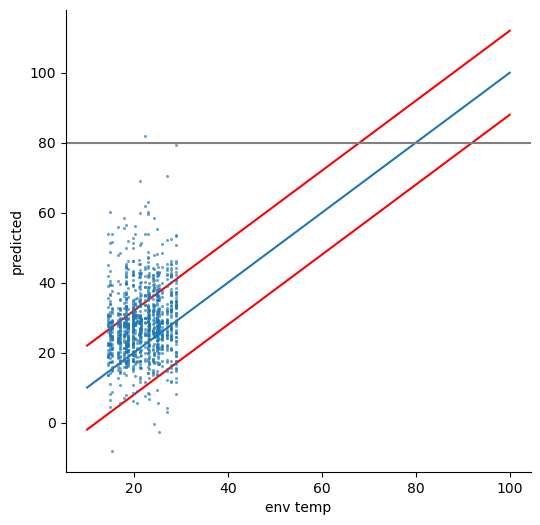

In [172]:
plotdf = plot_predictions(col_datasets, y)

In [105]:
y.to_csv('./../data/validation_datasets/Shah2024/md/Shah2024_env_temps.tsv', sep='\t')

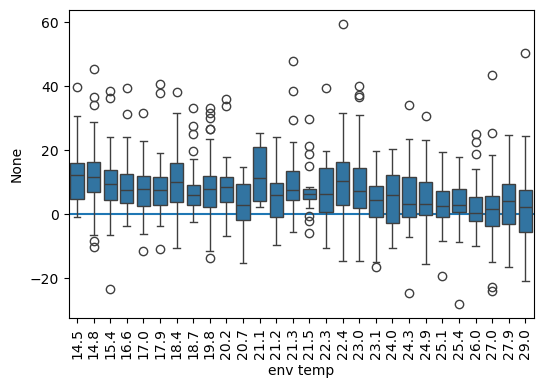

In [419]:
fig, ax = plt.subplots(figsize=(6,4))
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])
plt.tick_params(rotation=90, axis='x')

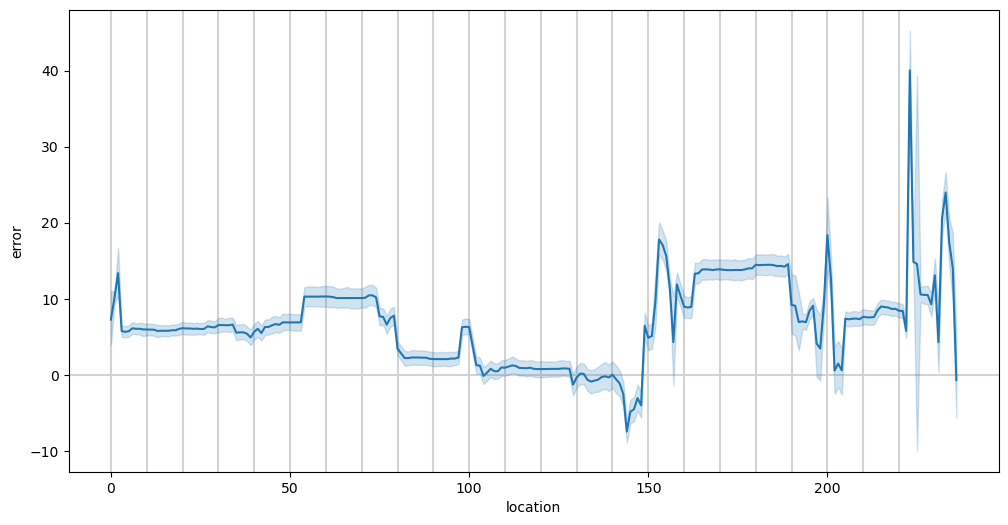

In [420]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [421]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
144,-7.448006
145,-4.833661
146,-4.526620
148,-4.016139
147,-3.055262
...,...
153,17.801854
200,18.366343
232,20.600063


In [422]:
plotdf.to_csv('./../data/validation_datasets/Shah2024/Shah2024_errors.tsv', sep='\t')

In [424]:
data = []
for index, row in shah2024_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
    
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [425]:
%%time
# compute representations from sixth layer
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 5min 4s, sys: 3min 12s, total: 8min 16s
Wall time: 38.6 s


In [426]:
# make a df
cls_embedding = pd.DataFrame(index=[l.split('|')[1] for l in labels], data=reps[:, 0, :])

In [427]:
tsne = TSNE(n_components=2, random_state=143, perplexity=50)
embedding_2d = tsne.fit_transform(cls_embedding)

In [428]:
plotdf = pd.DataFrame(embedding_2d, index=cls_embedding.index)

In [429]:
plotdf.head()

,0,1
scaffolds_hmmsearch.tbl,-2.864906,-17.039801
scaffolds_hmmsearch.tbl,-36.965279,-14.701384
scaffolds_hmmsearch.tbl,29.622263,8.788299
scaffolds_hmmsearch.tbl,-23.567587,-15.435713
scaffolds_hmmsearch.tbl,-37.841209,-16.255636


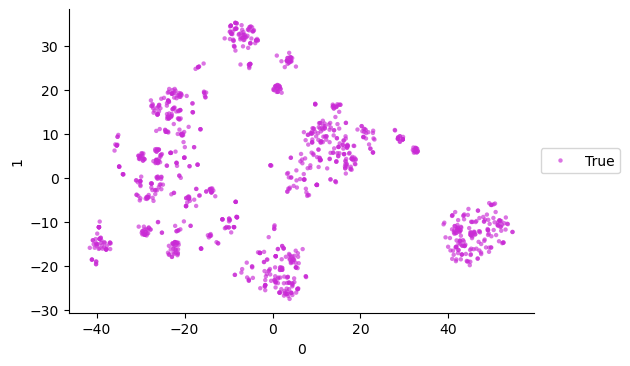

In [430]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, x=0, y=1, s=10, hue=plotdf.index.str.contains('tbl'), palette='gnuplot2', 
                linewidth=0, alpha=0.65)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_aspect('equal')
sns.despine()
plt.show()


In [431]:
cls_embedding.to_csv('./../data/validation_datasets/Shah2024/Shah2024_embedding.tsv', sep='\t')

# Australia

## 1. Get sample IDs

In [214]:
with open('./../base_api_key.txt', 'r') as handle:
    api_key = handle.read()

In [215]:
import ckanapi
remote = ckanapi.RemoteCKAN('https://data.bioplatforms.com', apikey=api_key)
# we increase the number of rows to be returned, and we
# ask for all packages, including private packages
result = remote.action.package_search(
    q='type:base-metagenomics',
    rows=50000,
    include_private=True)
print("{} matches found.".format(result['count']))

447 matches found.


In [28]:
[r['sample_extraction_id'] for r in result['results']]

['9588_1',
 '9586_1',
 '9576_1',
 '9573_1',
 '9571_1',
 '9569_1',
 '9567_1',
 '9530_1',
 '9528_2',
 '9526_2',
 '9524_1',
 '9522_1',
 '9514_1',
 '9512_1',
 '9510_1',
 '9508_1',
 '9506_1',
 '9504_1',
 '9502_1',
 '9500_1',
 '9498_1',
 '9496_1',
 '9494_1',
 '9492_1',
 '9490_1',
 '9488_1',
 '9486_1',
 '9484_1',
 '9468_1',
 '9466_1',
 '9466_1',
 '9464_1',
 '9462_1',
 '9460_1',
 '9458_1',
 '9456_1',
 '9454_1',
 '9452_1',
 '9450_1',
 '9450_1',
 '9448_1',
 '9446_1',
 '9444_1',
 '9442_1',
 '9440_1',
 '9438_1',
 '9436_1',
 '9434_1',
 '9432_1',
 '9430_1',
 '8531_1',
 '8531_1',
 '8529_1',
 '8527_1',
 '8527_1',
 '8525_1',
 '8523_1',
 '8523_1',
 '8521_1',
 '8519_1',
 '8517_1',
 '8515_1',
 '8513_1',
 '8511_1',
 '8509_1',
 '8507_1',
 '8497_1',
 '8497_1',
 '8495_1',
 '8493_1',
 '8491_1',
 '8489_1',
 '8487_1',
 '8461_1',
 '8461_1',
 '8459_2',
 '8457_2',
 '8455_2',
 '8271_2',
 '8271_2',
 '8270_2',
 '8269_2',
 '8269_2',
 '8268_2',
 '8268_2',
 '8263_2',
 '8263_2',
 '8262_2',
 '8262_2',
 '8164_1',
 '8164_1',

## 2. Assemble and annotate metagenomes

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [106]:
# make mapping of sequence ID to sample ID
aus_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Australia/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            aus_record2sample[r.id] = t.split("/")[-2].replace('_spades', '').split('_')[0]

## parse metadata

In [107]:
aus_md = pd.read_csv('./../data/validation_datasets/Australia/md/metadata_331.txt', sep='\t')
aus_md['Sample'] = aus_md['Sample'].apply(lambda x: x.lstrip('X'))

In [108]:
aus_md['bio1']

0      17.55267
1      17.58800
2      17.61733
3      17.46267
4      12.64583
         ...   
326     7.36600
327     7.28467
328     6.69100
329     9.63867
330     9.63867
Name: bio1, Length: 331, dtype: float64

In [109]:
y =  pd.merge(pd.Series(aus_record2sample).reset_index(), 
              aus_md[['Sample', 'bio1']],
             left_on=0, right_on='Sample').rename(columns={'bio1':'env temp', 
                                                        'Sample':'sample_or_genome', 'index':'protein'}).drop(0, axis=1)

y

,protein,sample_or_genome,env temp
0,NODE_3158_length_2801_cov_1.389658_2|scaffolds...,10714,17.55267
1,NODE_3427_length_2716_cov_4.868846_2|scaffolds...,10714,17.55267
2,NODE_6928_length_2034_cov_2.804952_1|scaffolds...,10714,17.55267
3,NODE_9829_length_1740_cov_1.804748_1|scaffolds...,10714,17.55267
4,NODE_15715_length_1400_cov_1.133829_2|scaffold...,10714,17.55267
...,...,...,...
763,NODE_41327_length_962_cov_3.771775_2|scaffolds...,138526,13.18646
764,NODE_52409_length_871_cov_2.493873_2|scaffolds...,138526,13.18646
765,NODE_76034_length_749_cov_1.612392_1|scaffolds...,138526,13.18646
766,NODE_98262_length_675_cov_1.638710_1|scaffolds...,138526,13.18646


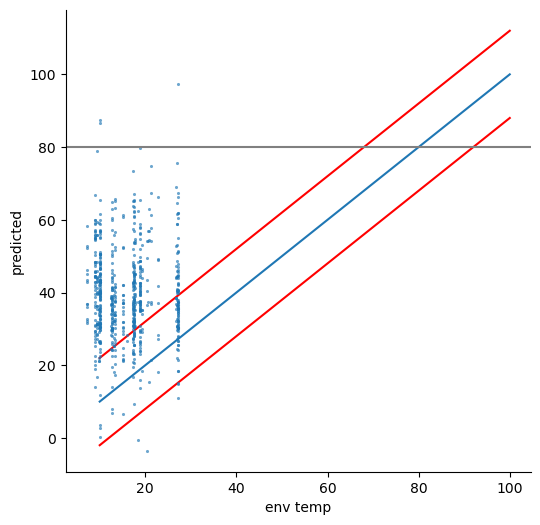

In [187]:
plotdf = plot_predictions(col_datasets, y)

# ax.set_title('Mycobacteria')

In [110]:
y.to_csv('./../data/validation_datasets/Australia/md/Australia_env_temps.tsv', sep='\t')

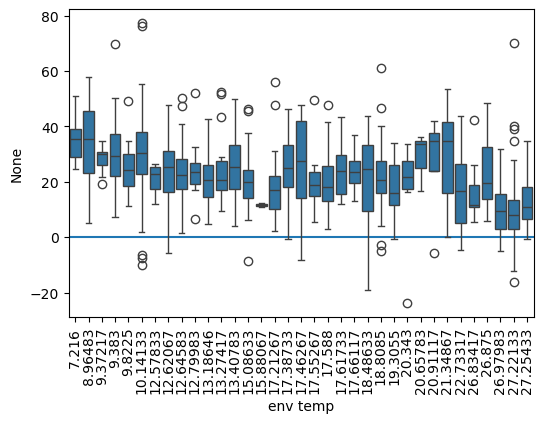

In [451]:
fig, ax = plt.subplots(figsize=(6,4))
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])
plt.tick_params(rotation=90, axis='x')

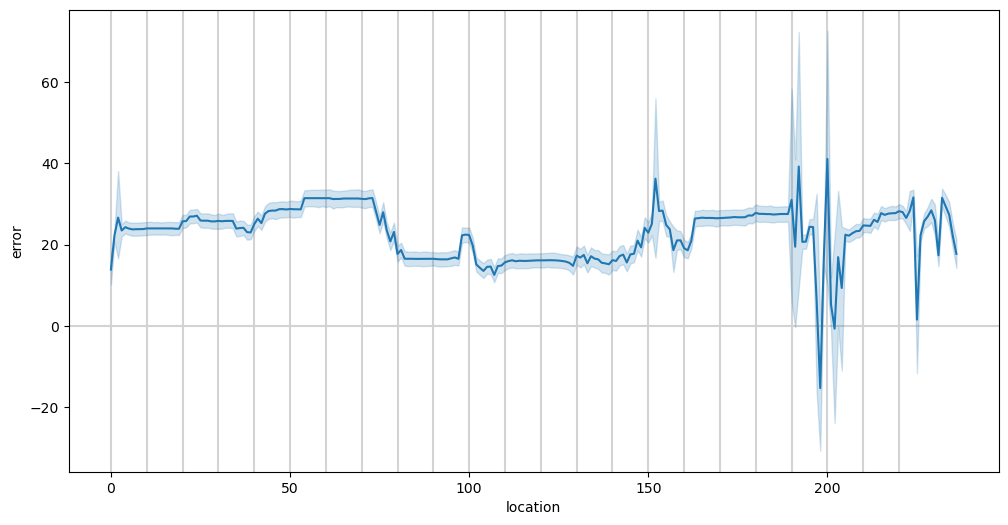

In [452]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [453]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
198,-15.290060
202,-0.674239
225,1.553827
201,5.291944
197,6.191741
...,...
232,31.515828
224,31.617669
152,36.216118


In [454]:
plotdf.to_csv('./../data/validation_datasets/Australia/Australia_errors.tsv', sep='\t')

# Antarctica

In [111]:
ant_md = pd.read_excel('./../data/validation_datasets/Antarctic/md/Dataset_S1_Metadata.xlsx', header=1)
ant_md

,Sample_ID,abbr_id,sample_location,location_group,LAT,LON,Elevation (m.a.s.l.),Distance from coast (km),pH_MQ,pH_KCl,...,Tl1908,V_2924,Zn2138,δ15NAIR (‰),δ13CVPDB (‰),Wt% N,Wt% C,C/N,Mean Annual Temp (oC),Annual Precipitation (mm/year)
0,AV1_1,AV,Shackleton Glacier,Shackleton Glacier,-85.176217,-174.088483,1471.07,71.2,6.628,5.766,...,2.0,31.12,35.74,-15.493,-34.477,0.144,0.012,0.086,-29.75,241.6
1,AV1_8,AV,Shackleton Glacier,Shackleton Glacier,-85.175950,-174.116533,1417.26,71.1,7.026,6.234,...,2.0,52.10,41.42,-7.376,-32.796,0.148,0.023,0.159,-29.95,243.0
2,AV2_1,AV,Shackleton Glacier,Shackleton Glacier,-85.170600,-174.133800,1404.25,70.5,7.791,7.198,...,2.0,46.62,38.17,-12.877,-25.955,0.030,0.034,1.134,-29.25,234.2
3,AV3_1,AV,Shackleton Glacier,Shackleton Glacier,-85.170683,-174.148300,1429.82,70.4,7.186,6.322,...,2.0,47.90,36.83,-17.971,-29.747,0.048,0.032,0.675,-29.25,234.4
4,AV3_7,AV,Shackleton Glacier,Shackleton Glacier,-85.167083,-174.150833,1367.45,70.1,6.776,5.233,...,2.0,25.15,49.00,0.588,-24.864,0.018,0.060,3.269,-29.35,234.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,WV_BA_1,WV,Wall Valley: Recon,Wall Valley,-77.495560,160.875170,1734.92,62.5,7.462,5.775,...,2.0,13.76,4.52,-9.947,-32.149,0.008,0.035,4.599,-30.45,114.1
196,WV_UNN1,WV,Wall Valley: Recon,Wall Valley,-77.480000,160.850000,1474.63,61.4,7.846,5.874,...,2.0,24.30,21.90,-8.628,-32.378,0.009,0.034,3.825,-30.95,104.1
197,WV_UNN3,WV,Wall Valley: Recon,Wall Valley,-77.480000,160.850000,1474.63,61.4,7.582,5.646,...,2.0,17.87,11.24,-11.027,-29.712,0.008,0.035,4.590,-30.95,104.1
198,WV_UNN_2,WV,Wall Valley: Recon,Wall Valley,-77.480000,160.850000,1474.63,61.4,7.672,5.841,...,2.0,25.60,18.15,-11.060,-31.543,0.008,0.032,4.098,-30.95,104.1


## 1. Assemble and annotate metagenomes

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [112]:
# make mapping of sequence ID to sample ID
ant_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Antarctic/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            ant_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [113]:
ant_record2sample

{'NODE_16_length_92306_cov_8.605710_14|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.2': 'BS610',
 'NODE_52_length_46706_cov_18.276008_3|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.4': 'BS610',
 'NODE_56_length_45654_cov_8.929394_45|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=148.0': 'BS610',
 'NODE_61_length_43867_cov_10.707741_40|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=170.9': 'BS610',
 'NODE_128_length_27827_cov_4.801045_23|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=162.4': 'BS610',
 'NODE_436_length_15166_cov_4.758698_17|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=165.7': 'BS610',
 'NODE_583_length_12578_cov_4.511799_8|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=135.8': 'BS610',
 'NODE_809_length_10819_cov_3.753770_15|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=180.9': 'BS610',
 'NODE_943_length_9991_cov_3.881682_16|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=152.8': 'BS610',
 'NODE_1290_length_8419_cov_2.555382_2|scaffolds_hmmsearch.tbl|XXXtemp=XXX|bitscore=162

## 2. More parsing of metadata

In [114]:
ant_md = pd.read_excel('./../data/validation_datasets/Antarctic/md/Dataset_S1_Metadata.xlsx', header=1)
ant_md['Sample_ID'] = ant_md['Sample_ID'].apply(lambda x: x.replace('_', '').replace('-', ''))
ant_md['Sample_ID'].unique()

array(['AV11', 'AV18', 'AV21', 'AV31', 'AV37', 'BP11', 'BP18', 'BP21',
       'BP31', 'BP38', 'BPS1', 'BPS18', 'BPS22', 'BPS25', 'BPS5', 'BS607',
       'BS610', 'BS618', 'BS620', 'CBCMBjA1', 'CBiH5', 'CK20B', 'CK1100B',
       'CK210', 'CK2100A', 'CK2100B', 'CM21', 'CM4', 'CMPA310', 'CMPA30',
       'CM20M', 'CR0819', 'CR0821', 'CR0826', 'CR0828', 'CR0833',
       'CSCR11', 'CSCR2', 'CSCR5', 'CSCR7', 'CSCR9', 'DA1', 'DA3', 'DA4',
       'DA5', 'DA6', 'DS112', 'DS212', 'GEA13', 'GEA22', 'GEB13', 'GEC23',
       'GEC32', 'HCBA1', 'HCBA2', 'HCZ51', 'HCZS2', 'HD10', 'HD11',
       'HD14', 'HD6', 'HD9', 'HG3', 'HG54', 'HG6', 'HG8', 'HG9', 'HH1',
       'HH2', 'HH3', 'HK1', 'HK2', 'HK3', 'HK4', 'HK5', 'HM2', 'HM3',
       'HM5', 'HM6', 'HR1', 'HR2', 'HR3', 'HR4', 'HR5', 'HS1', 'HS2',
       'HS3', 'HS4', 'HS7', 'HV18', 'HV25', 'HV31', 'HV39', 'HVY4A',
       'HVY5A', 'HVY9054A', 'HVY9062A', 'HVY9130A', 'KR1', 'KR2', 'KR4',
       'LC15', 'LC35', 'LC41', 'LGP34', 'LGPBA13', 'LGPBALV8', 'LSI1

In [115]:
ant_md.columns

Index(['Sample_ID', 'abbr_id', 'sample_location', 'location_group', 'LAT',
       'LON', 'Elevation (m.a.s.l.)', 'Distance from coast (km)', 'pH_MQ',
       'pH_KCl', 'pH_CaCl2', 'EC (uS/cm)', 'CEC (meq/100 g)', 'F-', 'Cl-',
       'NO3-', 'PO43-', 'SO42-', 'F-.1', 'Cl-.1', 'NO3-.1', 'PO43-.1',
       'SO42-.1', 'F-.2', 'Cl-.2', 'NO3-.2', 'PO43-.2', 'SO42-.2', 'Al3082',
       'As1890', 'B_2496', 'Ba4554', 'Be3130', 'Ca3158', 'Cd2288', 'Co2286',
       'Cr2835', 'Cu3247', 'Fe2599', 'Hg1849', 'K_7664', 'Li6707', 'Mg2852',
       'Mn2576', 'Mo2020', 'Na5895', 'Ni2316', 'P_1774', 'Pb2203', 'Sb2068',
       'Se1960', 'Si2516', 'Sn1899', 'Sr4077', 'Ti3349', 'Tl1908', 'V_2924',
       'Zn2138', 'δ15NAIR (‰)', 'δ13CVPDB (‰)', 'Wt% N', 'Wt% C', 'C/N',
       'Mean Annual Temp (oC)', 'Annual Precipitation (mm/year)'],
      dtype='object')

In [116]:
# y = pd.Series(index=ant_aln_df.index,
#           data=ant_md.set_index('Sample_ID')['Mean Annual Temp (oC)'].loc[[ant_record2sample[i] for i in ant_aln_df.index]].values,
#              name='env temp')

y =  pd.merge(pd.Series(ant_record2sample).reset_index(), 
              ant_md[['Sample_ID', 'Mean Annual Temp (oC)']],
             left_on=0, right_on='Sample_ID').rename(columns={'Mean Annual Temp (oC)':'env temp', 
                                                        'Sample_ID':'sample_or_genome', 'index':'protein'}).drop(0, axis=1)

y

,protein,sample_or_genome,env temp
0,NODE_16_length_92306_cov_8.605710_14|scaffolds...,BS610,-30.65
1,NODE_52_length_46706_cov_18.276008_3|scaffolds...,BS610,-30.65
2,NODE_56_length_45654_cov_8.929394_45|scaffolds...,BS610,-30.65
3,NODE_61_length_43867_cov_10.707741_40|scaffold...,BS610,-30.65
4,NODE_128_length_27827_cov_4.801045_23|scaffold...,BS610,-30.65
...,...,...,...
979,NODE_505_length_3468_cov_2.174285_1|scaffolds_...,TGV18,-25.55
980,NODE_865_length_2871_cov_1.971367_2|scaffolds_...,TGV18,-25.55
981,NODE_1407_length_2398_cov_1.458854_1|scaffolds...,TGV18,-25.55
982,NODE_1655_length_2241_cov_2.766636_3|scaffolds...,TGV18,-25.55


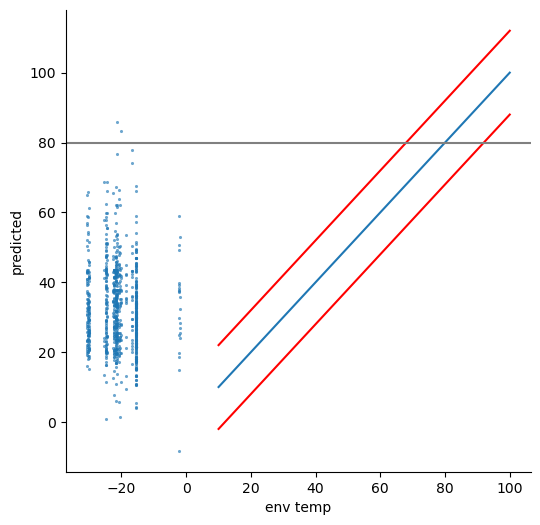

In [203]:
plotdf = plot_predictions(col_datasets, y)

# ax.set_title('Mycobacteria')

In [117]:
y.to_csv('./../data/validation_datasets/Antarctic/md/Antarctic_env_temps.tsv', sep='\t')

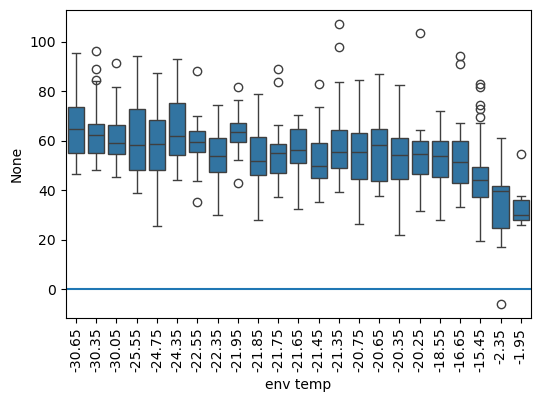

In [478]:
fig, ax = plt.subplots(figsize=(6,4))
plt.axhline(0)
sns.boxplot(y=plotdf['predicted'] - plotdf['env temp'],
                x=plotdf['env temp'])
plt.tick_params(rotation=90, axis='x')

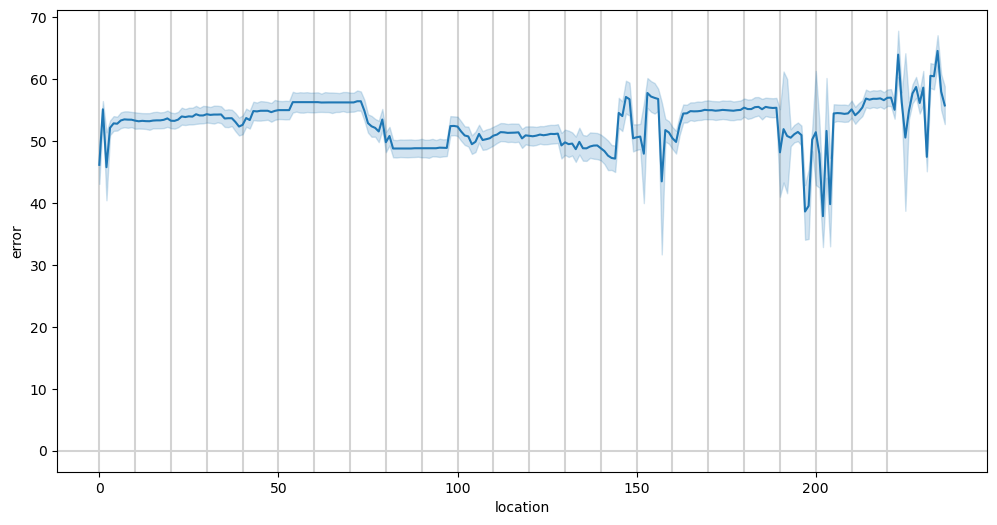

In [480]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [481]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
202,37.869550
197,38.623066
198,39.530241
204,39.807109
157,43.492985
...,...
228,58.729240
233,60.461328
232,60.539991


In [482]:
plotdf.to_csv('./../data/validation_datasets/Antarctic/Antarctic_errors.tsv', sep='\t')

# Youngblut 2020

## Step 1: get all of the samples

In [118]:
from jsonapi_client import Session
import pandas as pd
import requests

In [119]:
import json

def pp(json_obj):
    print(json.dumps(json_obj, indent=2))


In [120]:
gut_md = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/msystems.01045-20-st001.xlsx',
             sheet_name='Table S1C')

In [121]:
animals = pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/msystems.01045-20-st001.xlsx',
             sheet_name='Table S1B')['NCBI BioProject'].unique()

### Get ENA data

In [561]:
studies = ['PRJEB11755',
'PRJEB20308',
'PRJEB22765',
'PRJEB23642',
'PRJEB29346',
'PRJEB9357']

for study in studies:
    print(study)
    study_link = f'https://www.ebi.ac.uk/metagenomics/api/v1/studies/{study}'
    print(study_link)
    study_data = requests.get(study_link).json()
    sample_link = study_data['data']['relationships']['samples']['links']['related']

    sample_data = requests.get(sample_link).json()
    for sample in sample_data['data']:
        print(sample['id'])

PRJEB11755
https://www.ebi.ac.uk/metagenomics/api/v1/studies/PRJEB11755
ERS970154
ERS970155
ERS970156
ERS970157
ERS970158
ERS970159
ERS970160
ERS970161
ERS970162
ERS970163
ERS970164
ERS970165
ERS970166
ERS970167
ERS970168
ERS970169
ERS970170
ERS970171
ERS970172
ERS970173
ERS970174
ERS970175
ERS970176
ERS970177
ERS970178
PRJEB20308
https://www.ebi.ac.uk/metagenomics/api/v1/studies/PRJEB20308


KeyError: 'data'

In [600]:
# parse manually downloaded scripts
yb2020_ena_scripts = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/*.sh')

In [641]:
df_temp_list = []
for script in yb2020_ena_scripts:
    with open(script, 'r') as handle:
        lines = handle.readlines()

    # get prj name
    prj = script.split('/')[-1].split('-')[4]
    
    # get sample names
    full_names = set([l.split('/')[-1].strip() for l in sorted(lines)])
    
    # make df of prj -> run id
    prj_df = pd.DataFrame(list(np.unique([l.split('/')[-1].strip().split('_')[0] for l in sorted(lines)])), 
                          columns=['Run_ID']).assign(project=prj)
    
    # make sure both fwd and rev are present to confirm sample is paired
    # length of set(sample_1*, sample_2*).intersection(all) should be 2
    prj_df['is_paired'] = prj_df['Run_ID'].apply(lambda x: len(set([ext for ext in [f'{x}_{i}.fastq.gz' for i in [1,2]]]).intersection(full_names)) == 2)

    df_temp_list.append(prj_df)

In [649]:
yb2020_ena = pd.concat(df_temp_list)
yb2020_ena.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/ena_srrs.csv')

In [650]:
subset = yb2020_ena.groupby(['project']).apply(lambda x: x[x.is_paired].head(100).drop('project', axis=1)).reset_index()
subset.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/subset_ena_srrs.csv')

### NCBI side

In [567]:
from Bio import Entrez
import time

In [575]:


Entrez.email = "miho1832@colorado.edu"  # Required by NCBI

def get_sra_run_accessions(bioproject_id):


    """Return list of SRR IDs for a given BioProject ID."""
    # Step 1: Search SRA database for BioProject
    handle = Entrez.esearch(db="sra", term=f"{bioproject_id}[BioProject]", retmax=100000)
    record = Entrez.read(handle)
    handle.close()
    
    sra_ids = record['IdList']
    if not sra_ids:
        print('None found')
        return []
    
    run_accessions = []
    
    # Step 2: Fetch metadata for each entry
    for sra_id in sra_ids:
        handle = Entrez.efetch(db="sra", id=sra_id, rettype="runinfo", retmode="text")
        run_info = handle.read().decode()
        handle.close()
    
        # Parse CSV-like output
        lines = run_info.strip().split("\n")
        if len(lines) > 1:
            headers = lines[0].split(",")
            idx = headers.index("Run")
            for line in lines[1:]:
                fields = line.split(",")
                run_accessions.append(fields[idx])
    
        time.sleep(0.3)  # Respect NCBI rate limits
    
    return run_accessions


In [574]:
run_accessions

['SRR3327411', 'SRR3327343']

In [578]:
[f'PRJNA3165{60 + i}' for i in range(0, 11)]

['PRJNA316560',
 'PRJNA316561',
 'PRJNA316562',
 'PRJNA316563',
 'PRJNA316564',
 'PRJNA316565',
 'PRJNA316566',
 'PRJNA316567',
 'PRJNA316568',
 'PRJNA316569',
 'PRJNA316570']

In [590]:
bioprojects = [f'PRJNA3165{60 + i}' for i in range(0, 11)] + ['PRJNA336354',
'PRJNA381379',
'PRJNA417359',
'PRJNA476660',
'PRJNA485217',
'PRJNA532626']

yb_bp2srr = []

for bprj in bioprojects:
    print(bprj)
    accessions = get_sra_run_accessions(bprj)
    yb_bp2srr.append(pd.DataFrame(accessions).rename(columns={0:'Run_ID'}).assign(BioProject=bprj))

PRJNA316560
PRJNA316561
PRJNA316562
None found
PRJNA316563
PRJNA316564
None found
PRJNA316565
PRJNA316566
PRJNA316567
PRJNA316568
None found
PRJNA316569
None found
PRJNA316570
PRJNA336354
PRJNA381379
PRJNA417359
PRJNA476660
PRJNA485217
PRJNA532626


In [592]:
yb2020_ncbi = pd.concat(yb_bp2srr)

In [594]:
yb2020_ncbi['BioProject'].value_counts()

BioProject
PRJNA417359    495
PRJNA485217    105
PRJNA532626     25
PRJNA316566     24
PRJNA316563     20
PRJNA336354     15
PRJNA381379     14
PRJNA316567      5
PRJNA476660      4
PRJNA316560      2
PRJNA316570      2
PRJNA316561      1
PRJNA316565      1
Name: count, dtype: int64

In [652]:
yb2020_ncbi.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/ncbi_srrs.csv', index=False)
subset = yb2020_ncbi.groupby(['BioProject']).apply(lambda x: x.head(100).drop('BioProject', axis=1)).reset_index()
subset.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/subset_ncbi_srrs.csv')

from md folder:
```
cut -f 4 -d, subset_ena_srrs.csv > ena_accessions.txt
grep -h -f ena_accessions.txt *.sh | sort > ena_acc_download_script.sh
cut -f 4 -d, subset_ncbi_srrs.csv > ncbi_accessions.txt
```

In [655]:
yb2020_ncbi['BioProject'].unique()

array(['PRJNA316560', 'PRJNA316561', 'PRJNA316563', 'PRJNA316565',
       'PRJNA316566', 'PRJNA316567', 'PRJNA316570', 'PRJNA336354',
       'PRJNA381379', 'PRJNA417359', 'PRJNA476660', 'PRJNA485217',
       'PRJNA532626'], dtype=object)

In [663]:

print('#!/bin/bash\nrm -r'+'*\nrm -r '.join(list(yb2020_ncbi[yb2020_ncbi.BioProject.isin(['PRJNA316561', 'PRJNA316563', 'PRJNA316565',
       'PRJNA316566', 'PRJNA316567',])].sort_values('Run_ID')['Run_ID'].values)))

#!/bin/bash
SRR3303063*
rm -r SRR3303655*
rm -r SRR3303943*
rm -r SRR3303944*
rm -r SRR3303945*
rm -r SRR3303946*
rm -r SRR3303947*
rm -r SRR3303948*
rm -r SRR3303949*
rm -r SRR3303950*
rm -r SRR3303951*
rm -r SRR3303952*
rm -r SRR3303953*
rm -r SRR3303954*
rm -r SRR3303955*
rm -r SRR3303956*
rm -r SRR3303957*
rm -r SRR3303958*
rm -r SRR3303959*
rm -r SRR3303960*
rm -r SRR3303961*
rm -r SRR3303962*
rm -r SRR3303963*
rm -r SRR3303964*
rm -r SRR3303965*
rm -r SRR3303966*
rm -r SRR3307537*
rm -r SRR3307538*
rm -r SRR3307539*
rm -r SRR3310946*
rm -r SRR3315711*
rm -r SRR3333442*
rm -r SRR3333551*
rm -r SRR3333569*
rm -r SRR3333582*
rm -r SRR3333619*
rm -r SRR3333628*
rm -r SRR3333634*
rm -r SRR3333645*
rm -r SRR3333665*
rm -r SRR3333673*
rm -r SRR3333720*
rm -r SRR3333728*
rm -r SRR3333744*
rm -r SRR3333753*
rm -r SRR3333761*
rm -r SRR3333777*
rm -r SRR3333783*
rm -r SRR3333792*
rm -r SRR3333801*
rm -r SRR3333807


## 2. Assemble and annotate metagenomes

```
ls ./*_spades/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
genomes/*_spades/scaffolds_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

## 3. More metadata parsing

In [122]:
# make mapping of sequence ID to sample ID
yb_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Youngblut2020/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            yb_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [123]:
run_md = pd.merge(pd.read_excel('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/msystems.01045-20-st001.xlsx',
             sheet_name='Table S1B'),
         pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Youngblut2020/md/subset_ncbi_srrs.csv', index_col=0),
         left_on='NCBI BioProject', right_on='BioProject', how='inner')

In [124]:
body_temps = {
    "Chicken": 41.8,
    "Woodrat": 37.1,
    "Bar headed geese": 40.0,
    "Kakapo": 39.0,
    'Cow':38.6
}

In [125]:
mapper = run_md.set_index('Run_ID')['Host common name'].to_dict()
mapper['SRR3327411'] = 'Bar headed geese'
y = pd.Series(yb_record2sample).reset_index() 
y['env temp'] = y[0].map(mapper).map(body_temps)
y = y.rename(columns={'index':'protein', 0:'sample_or_genome'})

In [126]:
y

,protein,sample_or_genome,env temp
0,NODE_31_length_115180_cov_5.826067_21|scaffold...,SRR3327411,40.0
1,NODE_43_length_105063_cov_15.865629_59|scaffol...,SRR3327411,40.0
2,NODE_48_length_99316_cov_9.973817_31|scaffolds...,SRR3327411,40.0
3,NODE_51_length_96540_cov_13.100275_11|scaffold...,SRR3327411,40.0
4,NODE_83_length_82459_cov_17.568613_58|scaffold...,SRR3327411,40.0
...,...,...,...
653,NODE_1922_length_5725_cov_9.289771_8|scaffolds...,SRR6323401,41.8
654,NODE_1947_length_5641_cov_3.683136_2|scaffolds...,SRR6323401,41.8
655,NODE_2061_length_5384_cov_10.056859_2|scaffold...,SRR6323401,41.8
656,NODE_5588_length_2478_cov_3.345027_1|scaffolds...,SRR6323401,41.8


In [127]:
y['env temp'].value_counts()

env temp
41.8    481
40.0     68
39.0     22
Name: count, dtype: int64

## Actual predictions

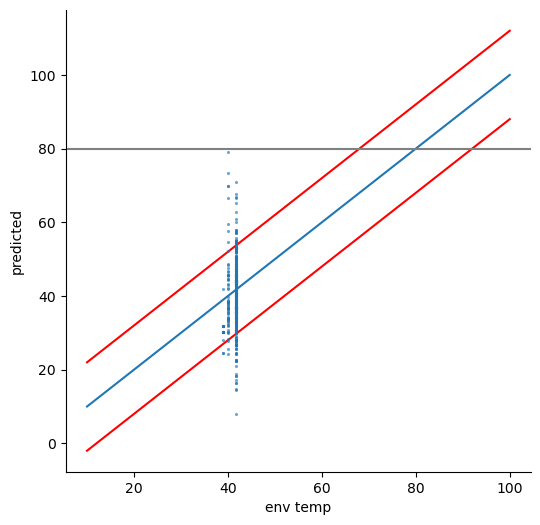

In [226]:
plotdf = plot_predictions(col_datasets, y)

In [128]:
y.to_csv('./../data/validation_datasets/Youngblut2020/md/Youngblut2020_env_temps.tsv', sep='\t')

# Conteville 

Just got a list of accessions from the paper

In [129]:
# make mapping of sequence ID to sample ID
cont2024_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Conteville2024/genomes/*_spades/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            cont2024_record2sample[r.id] = t.split("/")[-2].replace('_spades', '')

In [130]:
body_temps = {
    "Chicken": 41.8,
    "Woodrat": 37.1,
    "Bar headed geese": 40.0,
    "Kakapo": 39.0,
    'Cow':38.6
}

In [131]:
mapper = dict((s, 'Cow') for s in cont2024_record2sample.values())
y = pd.Series(cont2024_record2sample).reset_index() 
y['env temp'] = y[0].map(mapper).map(body_temps)
y = y.rename(columns={'index':'protein', 0:'sample_or_genome'})

In [132]:
y

,protein,sample_or_genome,env temp
0,NODE_21_length_121212_cov_10.147825_103|scaffo...,SRR25030028,38.6
1,NODE_46_length_95163_cov_21.825788_45|scaffold...,SRR25030028,38.6
2,NODE_119_length_59736_cov_7.347498_58|scaffold...,SRR25030028,38.6
3,NODE_366_length_33445_cov_10.088829_18|scaffol...,SRR25030028,38.6
4,NODE_527_length_26880_cov_5.798882_7|scaffolds...,SRR25030028,38.6
...,...,...,...
2206,NODE_147265_length_705_cov_2.356923_1|scaffold...,SRR25030045,38.6
2207,NODE_156636_length_678_cov_2.426966_1|scaffold...,SRR25030045,38.6
2208,NODE_188608_length_604_cov_1.316940_1|scaffold...,SRR25030045,38.6
2209,NODE_195344_length_591_cov_1.296642_1|scaffold...,SRR25030045,38.6


In [133]:
y['env temp'].value_counts()

env temp
38.6    2211
Name: count, dtype: int64

## Actual predictions

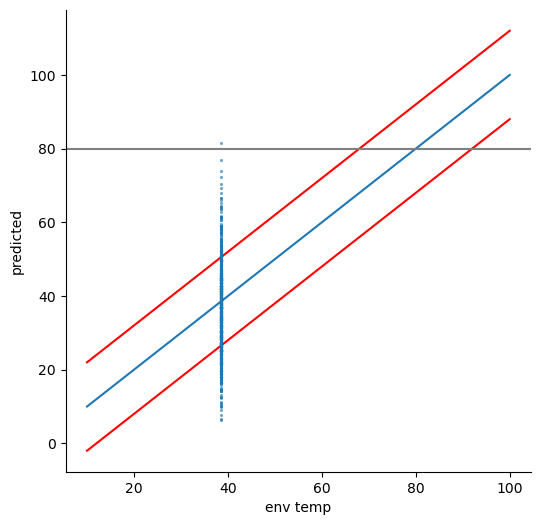

In [245]:
predictions = plot_predictions(col_datasets, y)

In [134]:
y.to_csv('./../data/validation_datasets/Conteville2024/md/Conteville2024_env_temps.tsv', sep='\t')

# Salazar 2019

## 1. Parse metadata

In [299]:
sample_md = pd.read_excel('./../data/validation_datasets/Salazar2019/md/Salazar_et_al_2019_Suppl_Info.xlsx',
                  sheet_name='Table_W1')

station_md = pd.read_excel('./../data/validation_datasets/Salazar2019/md/Salazar_et_al_2019_Suppl_Info.xlsx',
                  sheet_name='Table_W6')

/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [341]:
errs = sample_md[sample_md['MetaG/MetaT'].eq('MetaG') & sample_md['Size_fraction_name'].eq('Prokaryote enriched')]['ENA_Run_ID']

In [342]:
prok_metag = list(set([i for e in errs for i in e.split('|')]))
with open('./../data/validation_datasets/Salazar2019/md/Salazar2019_prok_metag_errs.txt', 'w') as handle:
    handle.write('\n'.join(prok_metag))

In [343]:
# mapping of station to temperatures
station2temp = station_md.set_index(['Station.label', 'Layer'])['Temperature']
station2temp = station2temp.reset_index().rename(columns={'Station.label':'Station'})
station2temp.head()

,Station,Layer,Temperature
0,TARA_018,SRF,21.486650
1,TARA_025,DCM,15.181967
2,TARA_031,SRF,25.028100
3,TARA_032,SRF,25.811708
4,TARA_033,SRF,27.309700


In [345]:
# mapping of err to station and layer
err2station = pd.DataFrame()
for index, row in sample_md.iterrows():
    for item in row['ENA_Run_ID'].split('|'):
        err2station.loc[item, 'Station'] = f'TARA_{row["Station"]:03}'
        err2station.loc[item, 'Layer'] = row["Layer"]

err2station = err2station.rename_axis(index='Run').reset_index()
err2station.head()

,Run,Station,Layer
0,ERR594328,TARA_034,SRF
1,ERR594334,TARA_036,SRF
2,ERR594290,TARA_037,MES
3,ERR594345,TARA_037,MES
4,ERR594312,TARA_038,MES


In [346]:
collated_md = pd.merge(err2station,
                      station2temp,
                      how='outer', left_on=['Station', 'Layer'], right_on=['Station', 'Layer'])

In [347]:
print(collated_md.shape)
print(collated_md['Run'].shape)

(1074, 4)
(1074,)


In [348]:
collated_md.to_csv('./../data/validation_datasets/Salazar2019/md/collated_md.tsv', sep='\t')

In [352]:
# saving only prokaryotic mg samples WITH TEMPS THIS TIME (UGH)
prok_metag_temp = collated_md[collated_md['Run'].isin(prok_metag) & (~collated_md['Temperature'].apply(np.isnan))]['Run'].unique()
with open('./../data/validation_datasets/Salazar2019/md/Salazar2019_prok_metag_temp_errs.txt', 'w') as handle:
    handle.write('\n'.join(prok_metag_temp))

## 2. Process assemblies

```
ls ./*_final/scaffolds.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./ -n 100 -s 100
cat genomes/*_final/scaffolds_adk.faa > adks.faa
```
Align to highqual:
`mafft --add --keeplength adks.faa backbone.afa > Salazar2019_aln_to_backbone.afa`

## 3. Write adk_temps file

In [195]:
adk_files = glob.glob('./../data/validation_datasets/Salazar2019/genomes/*_final/*_adk.faa')
seq2sample = pd.Series()
for f in adk_files:
    with open(f, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, format='fasta')]
    for r in records:
        seq2sample.loc[r.id] = f.split('/')[-2].replace('_final', '')

In [196]:
collated_md = pd.read_csv('./../data/validation_datasets/Salazar2019/md/collated_md.tsv', sep='\t', index_col=0)

collated_md.head()

,Run,Station,Layer,Temperature
0,ERR594328,TARA_034,SRF,NaN
1,ERR598959,TARA_034,SRF,NaN
2,ERR598991,TARA_034,SRF,NaN
3,ERR594368,TARA_034,SRF,NaN
4,ERR594370,TARA_034,SRF,NaN


In [197]:
# make y here
merged = pd.merge(seq2sample.reset_index(),
         collated_md, left_on=0, right_on='Run',
         how='left')

y = merged[['index', 'Run', 'Temperature']].rename(columns={'index':'protein', 'Run':'sample_or_genome', 'Temperature':'env temp'})

In [199]:
y.to_csv('./../data/validation_datasets/Salazar2019/md/Salazar2019_env_temps.tsv', sep='\t')

In [327]:
collated_md[collated_md['Run'].eq('ERR315859')]

,Run,Station,Layer,Temperature
248,ERR315859,TARA_023,DCM,NaN


In [333]:
with open('./../data/validation_datasets/Salazar2019/adks.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

new_records = []
for r in records:
    
    samp = seq2sample.loc[r.id]
    temp = collated_md.set_index('Run').loc[samp, 'Temperature']
    if not np.isnan(temp):
        r.id = r.id.replace('XXXtemp=XXX', f'env_temp={temp}')
        r.description = ''
        new_records.append(r)

with open('./../data/validation_datasets/Salazar2019/adk_temps.faa', 'w') as handle:
    SeqIO.write(new_records, handle, format='fasta')
        

In [338]:
collated_md[~collated_md['Temperature'].apply(np.isnan)]

,Run,Station,Layer,Temperature
9,ERR594290,TARA_037,MES,11.984006
10,ERR594345,TARA_037,MES,11.984006
11,ERR599031,TARA_037,MES,11.984006
12,ERR599062,TARA_037,MES,11.984006
13,ERR599372,TARA_037,MES,11.984006
...,...,...,...,...
877,ERR2762186,TARA_210,SRF,5.295265
878,ERR2762187,TARA_210,SRF,5.295265
879,ERR2762188,TARA_210,SRF,5.295265
880,ERR3586691,TARA_210,SRF,5.295265


# Mara 2023

In [146]:
md = pd.read_csv('./../data/validation_datasets/Mara2023/md/Mara2023_SraRunTable.csv')

In [147]:
md.columns #['Library Source'].value_counts()

Index(['Run', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample',
       'BioSampleModel', 'Bytes', 'Center Name', 'Collection_Date', 'Consent',
       'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region',
       'Experiment', 'geo_loc_name_country', 'geo_loc_name_country_continent',
       'geo_loc_name', 'Instrument', 'lat_lon', 'Library Name',
       'LibraryLayout', 'LibrarySelection', 'LibrarySource', 'Organism',
       'Platform', 'ReleaseDate', 'create_date', 'version', 'Sample Name',
       'SRA Study', 'isolation_source', 'samp_collect_device', 'Depth_(mbsf)',
       'Depth', 'amplification_primers', 'depth_9mbsf)', 'elev',
       'env_broad_scale', 'env_local_scale', 'env_medium', 'rel_to_oxygen'],
      dtype='object')

In [148]:
md.groupby(['LibrarySource', 'Assay Type']).count() #.value_counts()

Run  AvgSpotLen  Bases  BioProject  BioSample  \
LibrarySource Assay Type                                                  
GENOMIC       AMPLICON     75          75     75          75         75   
METAGENOMIC   AMPLICON     41          41     41          41         41   
              WGA          29          29     29          29         29   
              WGS           8           8      8           8          8   

                          BioSampleModel  Bytes  Center Name  Collection_Date  \
LibrarySource Assay Type                                                        
GENOMIC       AMPLICON                75     75           75               75   
METAGENOMIC   AMPLICON                41     41           41               41   
              WGA                     29     29           29               29   
              WGS                      8      8            8                8   

                          Consent  ...  samp_collect_device  Depth_(mbsf)  \
LibrarySource Assay Type           ...                                      
GENOMIC       AMPLICON         75  ...                   75            54   
METAGENOMIC   AMPLICON         41  ...                   41            33   
              WGA              29  ...                   29            14   
              WGS               8  ...                    0             0   

                          Depth  amplification_primers  depth_9mbsf)  elev  \
LibrarySource Assay Type                                                     
GENOMIC       AMPLICON       21                     21             0     0   
METAGENOMIC   AMPLICON        8                      0             0     8   
              WGA             0                      0            15     0   
              WGS             0                      0             0     0   

                          env_broad_scale  env_local_scale  env_medium  \
LibrarySource Assay Type                                                 
GENOMIC       AMPLICON                  0                0           0   
METAGENOMIC   AMPLICON                  8                8           8   
              WGA                       0                0           0   
              WGS                       0                0           0   

                          rel_to_oxygen  
LibrarySource Assay Type                 
GENOMIC       AMPLICON                0  
METAGENOMIC   AMPLICON                0  
              WGA                     0  
              WGS                     8  

[4 rows x 40 columns]

In [149]:
md[['LibrarySource', 'Assay Type', 'Sample Name', 'Library Name']].query('`Library Name` == "1546B_1H2"')

,LibrarySource,Assay Type,Sample Name,Library Name
145,METAGENOMIC,AMPLICON,1546B_1H2pb,1546B_1H2


In [150]:
md[md['Assay Type'].eq('WGA') & md['LibrarySource'].eq('METAGENOMIC')][['Run', 'Sample Name']].to_csv('./../data/validation_datasets/Mara2023/md/mg_sra_data.tsv', sep='\t')

In [151]:
run2sample = md[md['Assay Type'].eq('WGA') & md['LibrarySource'].eq('METAGENOMIC')][['Run', 'Sample Name']].reset_index(drop=True)
run2sample['Sample Name'] = run2sample['Sample Name'].apply(lambda x: x.replace('-g', ''))
run2sample.head()

,Run,Sample Name
0,SRR22580794,1545B_4H2
1,SRR22580795,Kit-control
2,SRR22580796,1549B_3H2
3,SRR22580797,1548B_8H5
4,SRR22580798,1548B_4H7


In [152]:
sample_md = pd.read_excel('./../data/validation_datasets/Mara2023/md/41467_2023_43296_MOESM4_ESM.xlsx', sheet_name='Supplementary Data 1')

sample_md = sample_md[~sample_md['Temperature (Celsius)'].isnull()]

sample_md['sample'] = sample_md['sample'].apply(lambda x: x.replace('*', '').lstrip('U'))
sample_md.head()

,sample,Temperature (Celsius),Depth (mbsf),pH,Alkalinity (mM),Salinity,SO42- (mM),PO43- (uM),H2S (uM),NH4+ (mM),...,DOC (mg/L),DIC (mM),CaCO3 (wt%),TOC (wt%),TN (wt%),TOC/TN,Fe (uM),TOTAL HC [C9-C44] mg/kg,TOTAL SAT HC mg/kg,TOTAL PAHs (≥2 rings) ug/kg
1,1546B_1H2,2.8,0.8,8.0,5.1,35.0,27.7,12.4,428.0,0.7,...,21.8,2.2,8.2,4.36,0.52,9.7,1.6,225.0,10.10,240.580
2,1545B_1H2,5.3,1.7,8.0,6.0,35.0,26.9,33.9,44.1,0.5,...,24.2,2.4,0.1,4.87,0.61,9.3,2.5,208.0,8.51,299.050
3,1546B_3H2,6.2,16.4,8.1,7.3,35.9,26.7,28.7,1226.6,0.3,...,21.0,2.5,1.5,2.15,0.34,7.4,1.2,NaN,NaN,NaN
4,1545B_2H3,6.4,6.8,8.3,6.9,35.0,26.3,36.4,1220.5,0.5,...,24.2,2.4,12.4,4.03,0.63,7.4,4.0,NaN,NaN,NaN
5,1549B_3H2,6.4,16.5,7.8,18.7,35.0,17.5,98.1,2567.2,3.3,...,23.6,5.7,4.0,3.12,0.59,6.1,0.0,24.7,1.89,65.216


In [153]:
collated_md = pd.merge(run2sample, 
         sample_md[['sample', 'Temperature (Celsius)', 'Depth (mbsf)']],
        left_on='Sample Name', right_on='sample', how='inner').drop('Sample Name', axis=1)
collated_md.head()

,Run,sample,Temperature (Celsius),Depth (mbsf)
0,SRR22580794,1545B_4H2,10.4,24.3
1,SRR22580796,1549B_3H2,6.4,16.5
2,SRR22580797,1548B_8H5,62.4,69.5
3,SRR22580798,1548B_4H7,33.5,33.5
4,SRR22580799,1548B_2H3,13.7,8.9


In [154]:
collated_md.to_csv('./../data/validation_datasets/Mara2023/md/collated_md.tsv', sep='\t')

## Write adk_temps file

In [186]:
seq2sample.shape

(420,)

In [187]:
adk_files = glob.glob('./../data/validation_datasets/Mara2023/genomes/*_final/*_adk.faa')
seq2sample = pd.Series()
for f in adk_files:
    with open(f, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, format='fasta')]
    for r in records:
        seq2sample.loc[r.id] = f.split('/')[-2].replace('_final', '')

In [189]:
collated_md = pd.read_csv('./../data/validation_datasets/Mara2023/md/collated_md.tsv', sep='\t', index_col=0)

collated_md.head()

,Run,sample,Temperature (Celsius),Depth (mbsf)
0,SRR22580794,1545B_4H2,10.4,24.3
1,SRR22580796,1549B_3H2,6.4,16.5
2,SRR22580797,1548B_8H5,62.4,69.5
3,SRR22580798,1548B_4H7,33.5,33.5
4,SRR22580799,1548B_2H3,13.7,8.9


In [190]:
md[md.Run.str.contains('SRR23614671')]['Sample Name']

113    drilling_fluid-g
Name: Sample Name, dtype: object

In [191]:
# make y here
merged = pd.merge(seq2sample.reset_index(),
         collated_md, left_on=0, right_on='Run',
         how='left')

y = merged[['index', 'Run', 'Temperature (Celsius)']].rename(columns={'index':'protein', 'Run':'sample_or_genome', 'Temperature (Celsius)':'env temp'})

In [192]:
y

,protein,sample_or_genome,env temp
0,NODE_146_length_18975_cov_33.086258_14|scaffol...,SRR22580796,6.4
1,NODE_216_length_15544_cov_35.850604_6|scaffold...,SRR22580796,6.4
2,NODE_266_length_13403_cov_40.107057_18|scaffol...,SRR22580796,6.4
3,NODE_584_length_7954_cov_21.659324_7|scaffolds...,SRR22580796,6.4
4,NODE_800_length_6572_cov_21.634955_9|scaffolds...,SRR22580796,6.4
...,...,...,...
981,NODE_433105_length_595_cov_2.818519_1|scaffold...,SRR22580804,17.5
982,NODE_452626_length_582_cov_2.713472_1|scaffold...,SRR22580804,17.5
983,NODE_699425_length_469_cov_5.108696_1|scaffold...,SRR22580804,17.5
984,NODE_823091_length_435_cov_1.250000_1|scaffold...,SRR22580804,17.5


In [193]:
y.to_csv('./../data/validation_datasets/Mara2023/md/Mara2023_env_temps.tsv', sep='\t')

In [194]:
# with open('./../data/validation_datasets/Mara2023/adks.faa', 'r') as handle:
#     records = [r for r in SeqIO.parse(handle, format='fasta')]

# new_records = []
# for r in records:
    
#     samp = seq2sample.loc[r.id]
#     if samp in collated_md['Run'].values:
#         temp = collated_md.set_index('Run').loc[samp, 'Temperature (Celsius)']
#         if not np.isnan(temp):
#             r.id = r.id.replace('XXXtemp=XXX', f'env_temp={temp}')
#             r.description = ''
#             new_records.append(r)
#     else:
#         print(md[md.Run.str.contains(samp)]['Sample Name'])

# with open('./../data/validation_datasets/Mara2023/adk_temps.faa', 'w') as handle:
#     SeqIO.write(new_records, handle, format='fasta')
        

In [338]:
collated_md[~collated_md['Temperature'].apply(np.isnan)]

,Run,Station,Layer,Temperature
9,ERR594290,TARA_037,MES,11.984006
10,ERR594345,TARA_037,MES,11.984006
11,ERR599031,TARA_037,MES,11.984006
12,ERR599062,TARA_037,MES,11.984006
13,ERR599372,TARA_037,MES,11.984006
...,...,...,...,...
877,ERR2762186,TARA_210,SRF,5.295265
878,ERR2762187,TARA_210,SRF,5.295265
879,ERR2762188,TARA_210,SRF,5.295265
880,ERR3586691,TARA_210,SRF,5.295265


# Alignments

In [165]:
import subprocess

In [200]:
# add each adk faa to the backbone for predictions
adk_faas = glob.glob('./../data/validation_datasets/*/adks.faa')
base_path = './../data/high_qual_alignments/alignments_to_backbone'
backbone_faa = './../data/high_qual_alignments/backbone.afa'

In [167]:


for faa in adk_faas:
    
    dataset_name = faa.split('/')[-2]
    print(f'Running: {dataset_name}')
    command = f'mafft --keeplength --add {faa} {backbone_faa} > {base_path}/{dataset_name}_adk_to_backbone.afa'
    subprocess.run(command, shell=True, capture_output=True)

Running: Arthrobacter
Running: Mycobacteria
Running: Antarctic
Running: RoyoLlonch2021
Running: Australia
Running: Shah2024
Running: Colman2024
Running: Conteville2024
Running: Youngblut2020
Running: Salazar2019
Running: Mara2023


In [201]:
# dereplicate
for faa in adk_faas:
    
    dataset_name = faa.split('/')[-2]
    print(f'Running: {dataset_name}')
    command = f'mmseqs easy-linclust {faa} {faa.replace("adks.faa", "derep_adks")} tmp --min-seq-id 1.0 -c 1.0 --cov-mode 1'
    subprocess.run(command, shell=True, capture_output=True)

Running: Arthrobacter
Running: Mycobacteria
Running: Antarctic
Running: RoyoLlonch2021
Running: Australia
Running: Shah2024
Running: Colman2024
Running: Conteville2024
Running: Youngblut2020
Running: Salazar2019
Running: Mara2023


# Summary figures

In [57]:
files = glob.glob('./../data/validation_datasets/*/*_predictions.tsv')

In [73]:
dataset = pd.concat([pd.read_csv(f, sep='\t', index_col=0).assign(dataset=f.split('/')[-1].split('_pred')[0]).assign(file=os.path.abspath(f)) for f in files])

dataset2label = {'Antarctic':'Antarctic soil', 
                 'Australia':'Australian soil', 
                 'Coleman2024':'Hot spring genome assemblies', 
                 'RoyoLlonch2021':'Arctic ocean (TARA)', 
                 'Shah2024':'European freshwater lakes',
                'Youngblut2020':'Avian microbiomes',
                'Conteville2024':'Bovine microbiomes'}

dataset['dataset_label'] = dataset['dataset'].map(dataset2label)

In [74]:
plotdf = dataset.groupby(['dataset', 'env temp']).agg(predicted_mean=('predicted','mean'),
                                              predicted_std=('predicted','std')).reset_index()

In [75]:
dataset['dataset_label'].unique()

array(['Antarctic soil', 'Arctic ocean (TARA)', 'Australian soil',
       'European freshwater lakes', 'Hot spring genome assemblies',
       'Bovine microbiomes', 'Avian microbiomes'], dtype=object)

In [76]:
dataset = dataset.reset_index(drop=True)

In [77]:
dataset.head()

,predicted,protein,sample_or_genome,env temp,dataset,file,dataset_label
0,37.529408,NODE_56_length_45654_cov_8.929394_45|scaffolds...,BS610,-30.65,Antarctic,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,Antarctic soil
1,64.986510,NODE_583_length_12578_cov_4.511799_8|scaffolds...,BS610,-30.65,Antarctic,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,Antarctic soil
2,40.815247,NODE_9797_length_2488_cov_2.020324_2|scaffolds...,BS610,-30.65,Antarctic,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,Antarctic soil
3,25.743412,NODE_22511_length_1523_cov_2.973029_1|scaffold...,BS610,-30.65,Antarctic,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,Antarctic soil
4,32.500614,NODE_6861_length_3526_cov_3.622209_3|scaffolds...,BPS5,-24.35,Antarctic,/data/mhoffert/fiererlab/adenylate_kinase_ogt/...,Antarctic soil


## Make protein files

In [91]:
from collections import Counter

In [119]:
# get mapping of proteins to env temp
protein2envtemp = dataset.set_index('protein')['env temp']

# confirm that all proteins only have 1 temperature
c = Counter(list(protein2envtemp.dropna().index))

items_with_count_n = [item for item, count in c.items() if count != 1]

assert len(list(set([protein2envtemp.loc[i].value_counts().shape[0] == 1 for i in items_with_count_n]))) == 1

# groupby to avoid duplicates
protein2envtemp = dataset.groupby('protein').agg({'env temp':'first'})['env temp'].dropna()
protein2envtemp.head()

protein
ERZ7462166.102845-NODE-102847-length-1200-cov-44.395633_2|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=189.4   -1.649738
ERZ7462166.103859-NODE-103861-length-1193-cov-2.479789_1|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=189.1    -1.649738
ERZ7462166.108201-NODE-108203-length-1162-cov-3.102078_1|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=168.9    -1.649738
ERZ7462166.10899-NODE-10899-length-5745-cov-19.987873_1|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=184.4     -1.649738
ERZ7462166.1093-NODE-1093-length-29329-cov-48.335007_20|ERZ7462166_FASTA_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.9     -1.649738
Name: env temp, dtype: float64

In [125]:
adk_files = sorted(glob.glob('./../data/validation_datasets/*/adks.faa'))
aln_files = sorted(glob.glob('./../data/validation_datasets/*/keeplength_adk_nogap.afa'))
for _adk, _aln in zip(adk_files, aln_files):
    
    assert _adk.split('/')[-2] == _aln.split('/')[-2], 'files are not the same'
    print(f'Working on dataset {_adk.split("/")[-2]}')


    for curr_file in [_adk, _aln]:
        with open(curr_file, 'r') as in_handle:
            in_records = [r for r in SeqIO.parse(curr_file, format='fasta')]

        # go through records and add temperature
        out_records = []
        not_found = 0
        for r in in_records:
            try:
                r.id = r.id.replace('XXXtemp=XXX', f'env_temp={protein2envtemp.loc[r.id]}')
                r.description = ''
                out_records.append(r)
            except KeyError:
                not_found += 1
            
        with open(curr_file.replace('adk', 'adk_temp'), 'w') as out_handle:
            SeqIO.write(out_records, out_handle, format='fasta')
    
        print(f'Done. {not_found} of {len(in_records)} proteins not found')
    print()
             

Working on dataset Antarctic
Done. 80 of 984 proteins not found
Done. 8612 of 9516 proteins not found

Working on dataset Arthrobacter
Done. 53 of 53 proteins not found
Done. 8585 of 8585 proteins not found

Working on dataset Australia
Done. 49 of 768 proteins not found
Done. 8581 of 9300 proteins not found

Working on dataset Colman2024
Done. 76 of 996 proteins not found
Done. 8608 of 9528 proteins not found

Working on dataset Conteville2024
Done. 2211 of 2211 proteins not found
Done. 10743 of 10743 proteins not found

Working on dataset Mycobacteria
Done. 20 of 20 proteins not found
Done. 8552 of 8552 proteins not found

Working on dataset RoyoLlonch2021
Done. 400 of 8036 proteins not found
Done. 8932 of 16568 proteins not found

Working on dataset Shah2024
Done. 16 of 1191 proteins not found
Done. 8548 of 9723 proteins not found

Working on dataset Youngblut2020
Done. 97 of 658 proteins not found
Done. 8629 of 9190 proteins not found



In [121]:
protein2envtemp.loc[r.id]

KeyError: 'NODE_59052_length_482_cov_1.690867_1|scaffolds_hmmsearch.tbl|env_temp=41.8|bitscore=146.8'

In [79]:
for index, row in dataset.head().iterrows():
    print(row['file'])

/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Antarctic/Antarctic_predictions.tsv
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Antarctic/Antarctic_predictions.tsv
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Antarctic/Antarctic_predictions.tsv
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Antarctic/Antarctic_predictions.tsv
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Antarctic/Antarctic_predictions.tsv


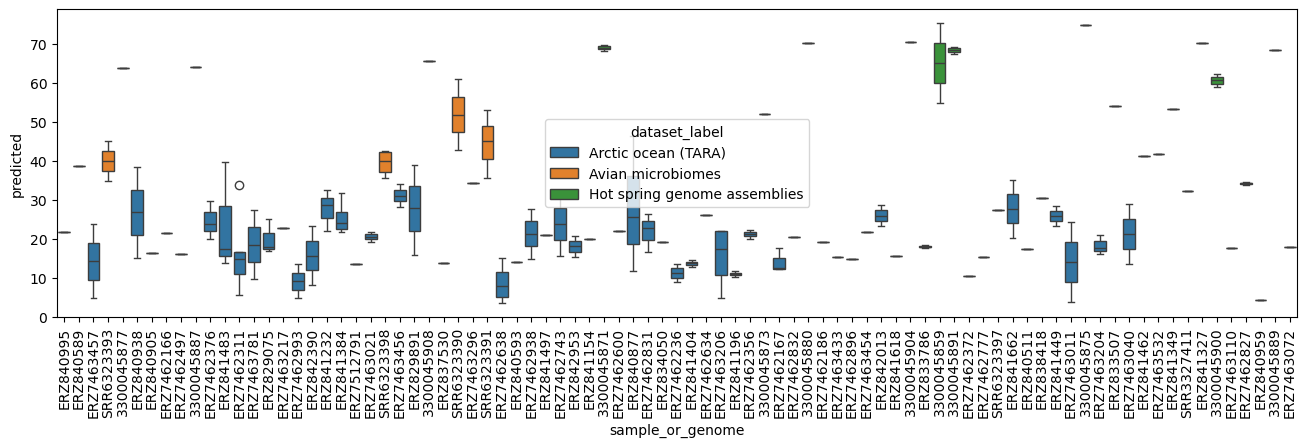

In [354]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.boxplot(data=dataset[dataset.dataset_label.isin(['Avian microbiomes', 'Arctic ocean (TARA)', 'Hot spring genome assemblies'])].sample(150), y='predicted', x='sample_or_genome', hue='dataset_label')
ax.tick_params(axis='x', rotation=90)

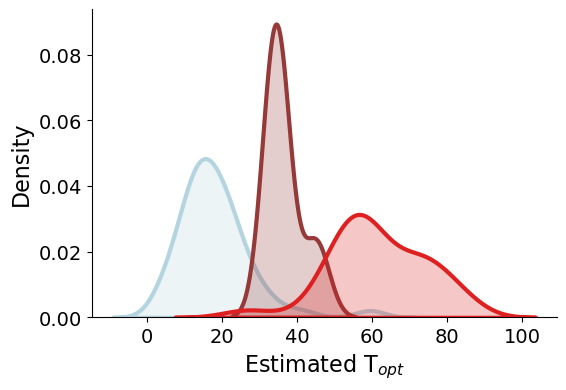

In [377]:
fig, ax = plt.subplots(figsize=(6,4))
g = sns.kdeplot(data=dataset[dataset.sample_or_genome.isin(['SRR6323393', 'ERZ7462993', '3300045859'])], 
                x='predicted', hue='dataset_label', #hist=False,
             ax=ax, common_norm=False, 
                palette = [sns.desaturate(i, 0.75) for i in ['lightblue', 'brown', 'red'][::-1]],
                hue_order=['Arctic ocean (TARA)', 'Avian microbiomes','Hot spring genome assemblies'][::-1],
                # kde=True, 
            #stat='density',
            fill=True, alpha=0.25, linewidth=3)
ax.set_xlabel('Estimated T$_{opt}$', fontsize=16)
ax.set_ylabel('Density', fontsize=16)
plt.tick_params(labelsize=14)
ax.get_legend().remove()
# lgd = ax.get_legend()
# lgd._loc = 6
# lgd.set_bbox_to_anchor((1, 0.5))
sns.despine()
plt.savefig('./../data/figures/20251017_threesample_example.png', dpi=400, bbox_inches='tight')

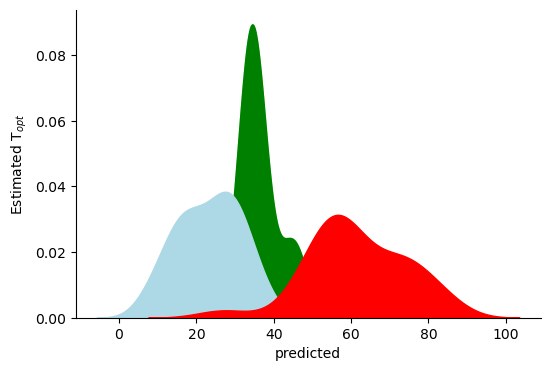

In [359]:
fig, ax = plt.subplots(figsize=(6,4))
g = sns.kdeplot(data=dataset[dataset.sample_or_genome.isin(['SRR6323393', 'ERZ829075', '3300045859'])], 
                x='predicted', hue='dataset_label', #hist=False,
             ax=ax, common_norm=False, 
                palette = ['sienna', 'chocolate', 'red',  'blue', 'lightblue', 'Green', 'lightgreen'],
                hue_order=[ 
                           'Antarctic soil',   'Australian soil','Hot spring genome assemblies',
       'European freshwater lakes', 'Arctic ocean (TARA)', 'Bovine microbiomes','Avian microbiomes',],
                # kde=True, 
            #stat='density',
            fill=True, alpha=1)
ax.set_ylabel('Estimated T$_{opt}$')
ax.get_legend().remove()
# lgd = ax.get_legend()
# lgd._loc = 6
# lgd.set_bbox_to_anchor((1, 0.5))
sns.despine()

In [333]:
dataset.groupby(['dataset_label', 'sample_or_genome'])[['predicted', 'env temp']].mean().reset_index()

,dataset_label,sample_or_genome,predicted,env temp
0,Antarctic soil,BPS5,39.777378,-24.35
1,Antarctic soil,BS610,35.201179,-30.65
2,Antarctic soil,BS620,33.311092,NaN
3,Antarctic soil,CBCMBjA1,33.191876,-30.35
4,Antarctic soil,CR0819,29.165532,-15.45
...,...,...,...,...
409,Hot spring genome assemblies,GCA_032249775.1,36.896300,84.00
410,Hot spring genome assemblies,GCA_032249795.1,61.835224,84.00
411,Hot spring genome assemblies,GCA_046533595.1,51.202305,72.60
412,Hot spring genome assemblies,GCA_046534135.1,28.615220,71.40


/tmp/ipykernel_2012001/805917272.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dataset[~(dataset['dataset_label'].eq('Hot spring genome assemblies') & \


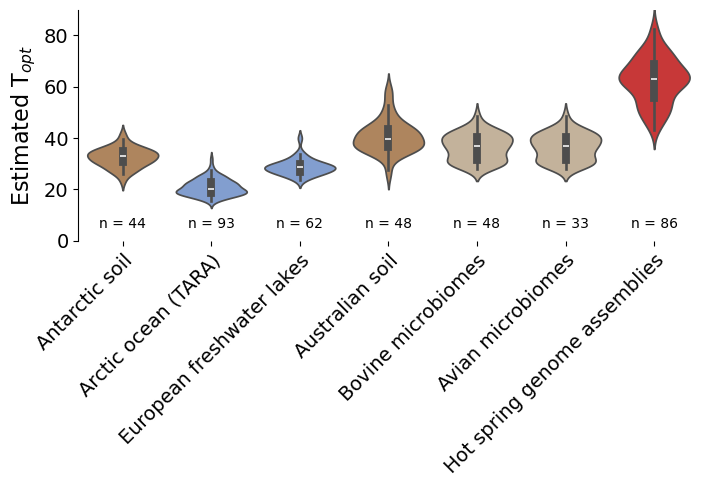

In [432]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(data=dataset[~(dataset['dataset_label'].eq('Hot spring genome assemblies') & \
                            (dataset['predicted'] < 40))].groupby(['dataset_label', 'sample_or_genome'])[['predicted', 'env temp']].mean().reset_index(),
               y='predicted', x='dataset_label', order=['Antarctic soil', 'Arctic ocean (TARA)', 
                                                          'European freshwater lakes', 'Australian soil', 
                                                          'Bovine microbiomes', 'Avian microbiomes', 'Hot spring genome assemblies'],
              palette=[sns.desaturate(i, 0.75) for i in ['peru', 'cornflowerblue', 'cornflowerblue', 'peru', 'tan', 'tan', 'red']], legend=False)

# sns.violinplot(data=dataset,
#                x='env temp', y='dataset_label', order=['Antarctic soil', 'Arctic ocean (TARA)', 
#                                                           'European freshwater lakes', 'Australian soil', 
#                                                           'Bovine microbiomes', 'Avian microbiomes', 'Hot spring genome assemblies'])

plt.tick_params(labelsize=14)
plt.tick_params(axis='x', rotation=45)
ax.set_ylabel('Estimated T$_{opt}$', fontsize=16)
ax.set_xlabel('')

for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')           # anchor to right end
    label.set_rotation_mode('anchor')  # rotate around the anchored point

for i, (label, count) in enumerate(dataset.groupby('dataset_label').apply(lambda x: len(x['sample_or_genome'].unique())).items()):
    ax.annotate(f'n = {count}', (i, 5), ha='center')

ax.set_ylim(0, 90)

sns.despine(bottom=True)
plt.savefig('./../data/figures/20251017_ESM2_metagenomics.png', dpi=400, bbox_inches='tight')

In [403]:
dataset.groupby('dataset_label').apply(lambda x: len(x['sample_or_genome'].unique())) #'sample_or_genome']).count()

dataset_label
Antarctic soil                  44
Arctic ocean (TARA)             93
Australian soil                 62
Avian microbiomes               48
Bovine microbiomes              48
European freshwater lakes       33
Hot spring genome assemblies    86
dtype: int64

In [ ]:
sns.scatterplot(data=dataset, x='env temp', y='predicted')

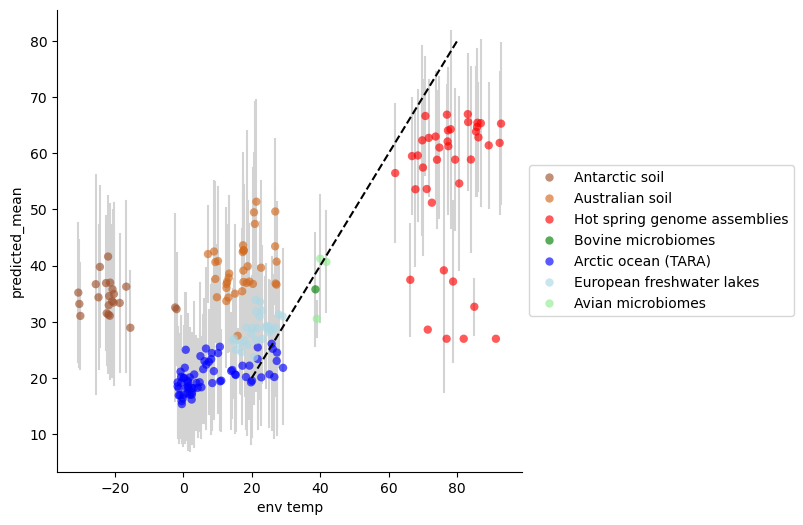

In [131]:
fig, ax = plt.subplots(figsize=(6,6))

palette = ['sienna', 'chocolate', 'red', 'Green',  'blue', 'lightblue', 'lightgreen']

sns.scatterplot(data=plotdf,
                x='env temp',
                y='predicted_mean',
                linewidth=0, alpha=0.65, hue='hue', palette=palette, zorder=2)

# ax = lineplot(plotdf, ax, 'hue', palette)

for index, row in plotdf.iterrows():
    # print('plotting')
    plt.plot((row['env temp'], row['env temp']), 
             (row['predicted_mean']+row['predicted_std'], 
              row['predicted_mean']-row['predicted_std']),
             color='lightgray',
             zorder=0
            ) 


plt.plot((20, 80), (20, 80), color='k', linestyle='--')

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()


In [133]:
files = glob.glob('./../data/validation_datasets/*/*_error*.tsv')

In [134]:
dataset = pd.concat([pd.read_csv(f, sep='\t').assign(dataset=f.split('/')[-1].split('_errors')[0]) for f in files])

/tmp/ipykernel_1735367/2164351726.py:2: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.lineplot(data=dataset, x='location', y='error', hue='dataset', palette=palette)


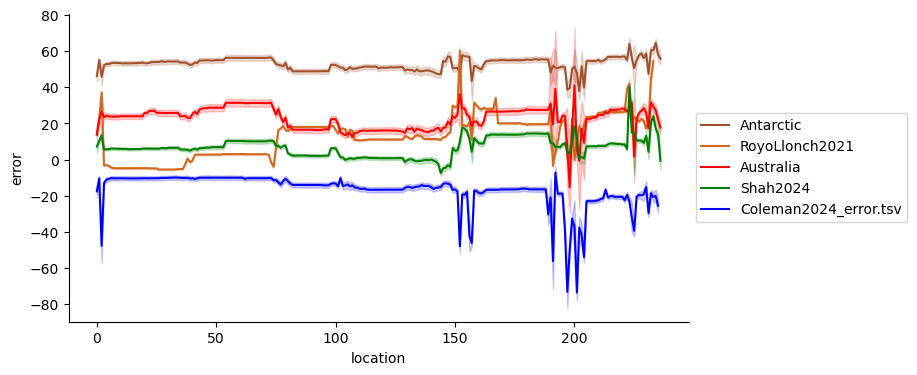

In [135]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=dataset, x='location', y='error', hue='dataset', palette=palette)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

# generating fastas of each dataset

In [55]:
files = glob.glob('./../data/validation_datasets/*/*_predictions.tsv')

In [56]:
pd.read_csv(f, sep='\t') for files

['./../data/validation_datasets/Antarctic/Antarctic_predictions.tsv',
 './../data/validation_datasets/RoyoLlonch2021/RoyoLlonch2021_predictions.tsv',
 './../data/validation_datasets/Australia/Australia_predictions.tsv',
 './../data/validation_datasets/Shah2024/Shah2024_predictions.tsv',
 './../data/validation_datasets/Colman2024/Coleman2024_predictions.tsv',
 './../data/validation_datasets/Conteville2024/Conteville2024_predictions.tsv',
 './../data/validation_datasets/Youngblut2020/Youngblut2020_predictions.tsv']